# Big Data Analytics & Recommendation System with PySpark

**Dataset:** MovieLens (ml-latest-small) — userId, movieId, rating, timestamp  
**Framework:** Apache Spark (PySpark) — DataFrame API  
**Objective:** End-to-end big data analytics pipeline and ALS-based collaborative filtering recommendation system.

---

## Table of Contents
1. [Introduction & Setup](#1)
2. [Data Loading & Inspection](#2)
3. [Data Cleaning & Transformation](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Insights](#5)
6. [Recommendation Model (ALS)](#6)
7. [Evaluation & Parameter Tuning](#7)
8. [Recommendations Output](#8)
9. [Conclusion](#9)

---
## 1. Introduction & Setup <a id='1'></a>

We use the **MovieLens ml-latest-small** dataset, which contains ~100,000 ratings from ~600 users across ~9,700 movies.  
The pipeline covers:
- Data ingestion, cleaning, and feature engineering using the Spark DataFrame API
- Exploratory analysis with 7+ visualisations
- Collaborative filtering via Alternating Least Squares (ALS)
- Model evaluation (RMSE) and hyperparameter tuning via cross-validation

### Architecture
```
Raw CSV  →  Spark DataFrame  →  Cleaning  →  Feature Eng.
                                                  ↓
                                             EDA + Charts
                                                  ↓
                                        ALS Train / Eval
                                                  ↓
                                         Recommendations
```

In [95]:
#!pip install pyspark matplotlib seaborn pandas


In [96]:
# ── Java 17 (required for PySpark 3.5+) ────────────────────────────────────────
import os
_JAVA_PATHS = [
    "/opt/homebrew/Cellar/openjdk@17/17.0.17/libexec/openjdk.jdk/Contents/Home",
    "/opt/homebrew/Cellar/openjdk/17.0.17/libexec/openjdk.jdk/Contents/Home",
    "/Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home",
]
for _jpath in _JAVA_PATHS:
    if os.path.isdir(_jpath):
        os.environ["JAVA_HOME"] = _jpath
        os.environ["PATH"] = os.path.join(_jpath, "bin") + ":" + os.environ.get("PATH","")
        print(f"JAVA_HOME → {_jpath}")
        break
else:
    print("WARNING: Java 17 not found — Spark may fail")

# ── Install dependencies (run once in a fresh environment) ─────────────────────
# !pip install pyspark matplotlib seaborn pandas

# ── Standard library ───────────────────────────────────────────────────────────
import os
import io
import zipfile
import urllib.request
import itertools

# ── PySpark ────────────────────────────────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    IntegerType, FloatType, LongType, StringType
)
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# ── Visualisation (pandas only for plotting — never for big-data ops) ──────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('All imports successful')

JAVA_HOME → /opt/homebrew/Cellar/openjdk@17/17.0.17/libexec/openjdk.jdk/Contents/Home
All imports successful


In [97]:
# ── Initialise SparkSession ────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName('MovieLens-RecommendationSystem')
    .master('local[*]')                          # use all local CPU cores
    .config('spark.driver.memory', '4g')          # enough headroom for model training
    .config('spark.sql.shuffle.partitions', '20') # reduced for small dataset
    .config('spark.ui.showConsoleProgress', 'false')
    .getOrCreate()
)

# Suppress verbose INFO logs — show WARN only
spark.sparkContext.setLogLevel('WARN')

print(f'Spark version : {spark.version}')
print(f'App name      : {spark.sparkContext.appName}')
print(f'Spark UI      : {spark.sparkContext.uiWebUrl}')

Spark version : 4.1.1
App name      : MovieLens-RecommendationSystem
Spark UI      : http://192.168.1.6:4040


---
## 2. Data Loading & Inspection <a id='2'></a>

### 2.1 Download MovieLens ml-latest-small

In [98]:
DATA_DIR     = 'data/movielens'
RATINGS_PATH = os.path.join(DATA_DIR, 'ratings.csv')
MOVIES_PATH  = os.path.join(DATA_DIR, 'movies.csv')

ML_URL = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'

if not os.path.exists(RATINGS_PATH):
    print('Downloading MovieLens dataset ...')
    os.makedirs(DATA_DIR, exist_ok=True)
    with urllib.request.urlopen(ML_URL) as resp:
        zf = zipfile.ZipFile(io.BytesIO(resp.read()))
    for name in zf.namelist():
        if name.endswith('ratings.csv'):
            with open(RATINGS_PATH, 'wb') as f:
                f.write(zf.read(name))
        elif name.endswith('movies.csv'):
            with open(MOVIES_PATH, 'wb') as f:
                f.write(zf.read(name))
    print('Download complete')
else:
    print('Dataset already cached locally')

print(f'  Ratings : {RATINGS_PATH}')
print(f'  Movies  : {MOVIES_PATH}')

Dataset already cached locally
  Ratings : data/movielens/ratings.csv
  Movies  : data/movielens/movies.csv


### 2.2 Define Schemas & Load

In [99]:
# Explicit schemas avoid the costly schema-inference scan on large files
ratings_schema = StructType([
    StructField('userId',    IntegerType(), nullable=False),
    StructField('movieId',   IntegerType(), nullable=False),
    StructField('rating',    FloatType(),   nullable=False),
    StructField('timestamp', LongType(),    nullable=False),
])

movies_schema = StructType([
    StructField('movieId', IntegerType(), nullable=False),
    StructField('title',   StringType(),  nullable=False),
    StructField('genres',  StringType(),  nullable=True),
])

ratings_raw = (
    spark.read
    .option('header', 'true')
    .schema(ratings_schema)
    .csv(RATINGS_PATH)
)

movies_raw = (
    spark.read
    .option('header', 'true')
    .schema(movies_schema)
    .csv(MOVIES_PATH)
)

print(f'Ratings rows : {ratings_raw.count():,}')
print(f'Movies  rows : {movies_raw.count():,}')

Ratings rows : 100,836
Movies  rows : 9,742


In [100]:
# ── Inspect schemas ────────────────────────────────────────────────────────────
print('Ratings schema:')
ratings_raw.printSchema()

print('Movies schema:')
movies_raw.printSchema()

Ratings schema:
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: long (nullable = true)

Movies schema:
root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)



In [101]:
# ── Sample rows ────────────────────────────────────────────────────────────────
print('Ratings sample (5 rows):')
ratings_raw.show(5, truncate=False)

print('Movies sample (5 rows):')
movies_raw.show(5, truncate=False)

Ratings sample (5 rows):
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|
|1     |3      |4.0   |964981247|
|1     |6      |4.0   |964982224|
|1     |47     |5.0   |964983815|
|1     |50     |5.0   |964982931|
+------+-------+------+---------+
only showing top 5 rows
Movies sample (5 rows):
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       

In [102]:
# ── Descriptive statistics ─────────────────────────────────────────────────────
print('Ratings descriptive statistics:')
ratings_raw.describe('userId', 'movieId', 'rating').show()

n_users   = ratings_raw.select('userId').distinct().count()
n_movies  = ratings_raw.select('movieId').distinct().count()
n_ratings = ratings_raw.count()
sparsity  = 1.0 - (n_ratings / (n_users * n_movies))

print(f'Distinct users  : {n_users:,}')
print(f'Distinct movies : {n_movies:,}')
print(f'Total ratings   : {n_ratings:,}')
print(f'Matrix sparsity : {sparsity:.4%}')

Ratings descriptive statistics:
+-------+------------------+----------------+------------------+
|summary|            userId|         movieId|            rating|
+-------+------------------+----------------+------------------+
|  count|            100836|          100836|            100836|
|   mean|326.12756356856676|19435.2957177992| 3.501556983616962|
| stddev| 182.6184914635004|35530.9871987003|1.0425292390606342|
|    min|                 1|               1|               0.5|
|    max|               610|          193609|               5.0|
+-------+------------------+----------------+------------------+

Distinct users  : 610
Distinct movies : 9,724
Total ratings   : 100,836
Matrix sparsity : 98.3000%


In [103]:
# ── Null / missing value audit ─────────────────────────────────────────────────
null_counts_ratings = ratings_raw.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in ratings_raw.columns
])
print('Null counts (ratings):')
null_counts_ratings.show()

null_counts_movies = movies_raw.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in movies_raw.columns
])
print('Null counts (movies):')
null_counts_movies.show()

Null counts (ratings):
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+

Null counts (movies):
+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+



---
## 3. Data Cleaning & Transformation <a id='3'></a>

### 3.1 Cleaning

In [104]:
ratings_clean = (
    ratings_raw
    # Remove rows containing any null value
    .dropna()
    # Keep one rating per user-movie pair (deterministic: keep latest by timestamp)
    .dropDuplicates(['userId', 'movieId'])
    # Enforce the valid MovieLens rating range [0.5, 5.0]
    .filter(F.col('rating').between(0.5, 5.0))
    # Reject non-positive IDs (data corruption guard)
    .filter((F.col('userId') > 0) & (F.col('movieId') > 0))
)

rows_removed = ratings_raw.count() - ratings_clean.count()
print(f'Rows removed : {rows_removed:,}')
print(f'Rows kept    : {ratings_clean.count():,}')

Rows removed : 0
Rows kept    : 100,836


### 3.2 Feature Engineering

In [105]:
# Derive time features from Unix epoch and add a categorical rating label
ratings = (
    ratings_clean
    # Unix seconds → TimestampType
    .withColumn('event_ts',    F.to_timestamp(F.col('timestamp')))
    .withColumn('year',        F.year('event_ts'))
    .withColumn('month',       F.month('event_ts'))
    .withColumn('day_of_week', F.dayofweek('event_ts'))  # 1=Sunday, 7=Saturday
    .withColumn('hour',        F.hour('event_ts'))
    # Ordinal rating bucket useful for classification/segment analysis
    .withColumn(
        'rating_category',
        F.when(F.col('rating') <= 2.0, 'Low')
         .when(F.col('rating') <= 3.5, 'Medium')
         .otherwise('High')
    )
    .drop('timestamp')  # replaced by structured time columns
)

# Cache here — this DataFrame is reused by every downstream operation
ratings.cache()

print('Enriched schema:')
ratings.printSchema()
ratings.show(5, truncate=False)

Enriched schema:
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- event_ts: timestamp (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- rating_category: string (nullable = false)

+------+-------+------+-------------------+----+-----+-----------+----+---------------+
|userId|movieId|rating|event_ts           |year|month|day_of_week|hour|rating_category|
+------+-------+------+-------------------+----+-----+-----------+----+---------------+
|1     |296    |3.0   |2000-07-30 14:49:27|2000|7    |1          |14  |Medium         |
|1     |608    |5.0   |2000-07-30 14:48:51|2000|7    |1          |14  |High           |
|1     |648    |3.0   |2000-07-30 14:42:43|2000|7    |1          |14  |Medium         |
|1     |1208   |4.0   |2000-07-30 14:54:10|2000|7    |1          |14  |High           

In [106]:
# ── Per-movie aggregate statistics ────────────────────────────────────────────
movie_stats = (
    ratings.groupBy('movieId')
    .agg(
        F.round(F.avg('rating'),    4).alias('avg_rating'),
        F.count('rating')            .alias('num_ratings'),
        F.round(F.stddev('rating'), 4).alias('std_rating'),
    )
    .join(movies_raw.select('movieId', 'title', 'genres'), on='movieId', how='left')
)
movie_stats.cache()

print('Movie statistics (top 10 by num_ratings):')
movie_stats.orderBy(F.desc('num_ratings')).show(10, truncate=False)

# ── Per-user aggregate statistics ─────────────────────────────────────────────
user_stats = (
    ratings.groupBy('userId')
    .agg(
        F.count('rating')            .alias('num_ratings'),
        F.round(F.avg('rating'), 4)  .alias('avg_rating_given'),
    )
)
user_stats.cache()

print('User statistics (top 10 most active):')
user_stats.orderBy(F.desc('num_ratings')).show(10)

Movie statistics (top 10 by num_ratings):
+-------+----------+-----------+----------+-----------------------------------------+--------------------------------+
|movieId|avg_rating|num_ratings|std_rating|title                                    |genres                          |
+-------+----------+-----------+----------+-----------------------------------------+--------------------------------+
|356    |4.1641    |329        |0.8312    |Forrest Gump (1994)                      |Comedy|Drama|Romance|War        |
|318    |4.429     |317        |0.713     |Shawshank Redemption, The (1994)         |Crime|Drama                     |
|296    |4.1971    |307        |0.952     |Pulp Fiction (1994)                      |Comedy|Crime|Drama|Thriller     |
|593    |4.1613    |279        |0.854     |Silence of the Lambs, The (1991)         |Crime|Horror|Thriller           |
|2571   |4.1924    |278        |0.9752    |Matrix, The (1999)                       |Action|Sci-Fi|Thriller          |
|260  

---
## 4. Exploratory Data Analysis (EDA) <a id='4'></a>

In [107]:
def to_pandas(spark_df, limit=1000):
    """Safely collect a small Spark aggregate to pandas for plotting.
    Using limit() ensures we never accidentally collect a full large table.
    """
    return spark_df.limit(limit).toPandas()

### 4.1 Rating Value & Category Distribution

/var/folders/_9/49lsnmp540lfvlfnj4mg00z80000gn/T/ipykernel_21285/2608741318.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating_dist_pd, x='rating', y='count',


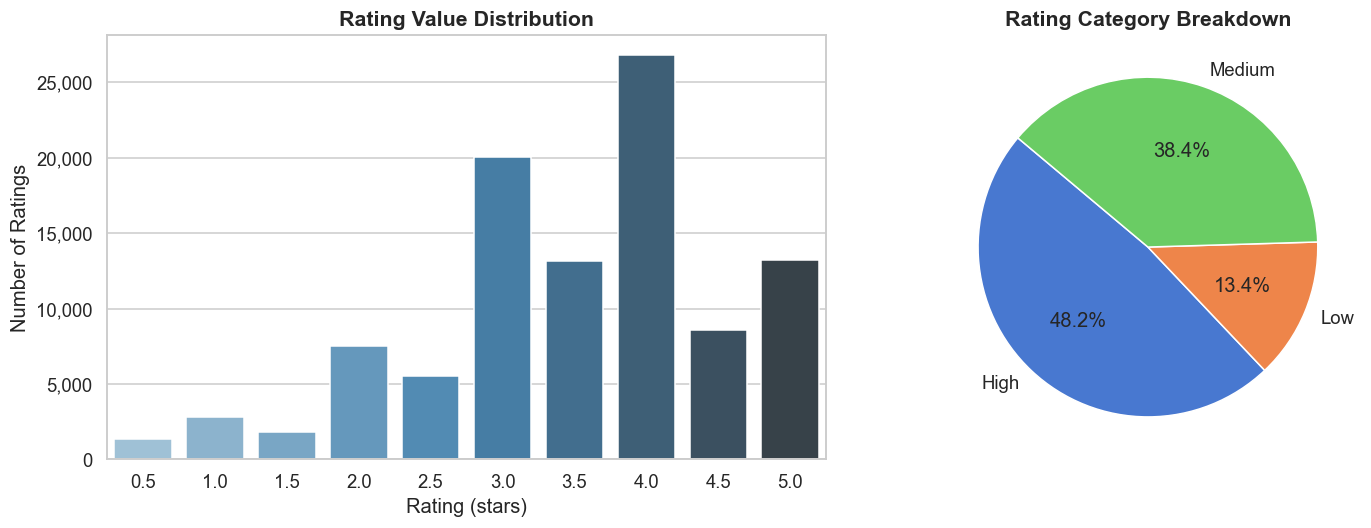

Saved: chart_01_rating_distribution.png


In [108]:
rating_dist_pd = to_pandas(
    ratings.groupBy('rating').count().orderBy('rating')
)

cat_dist_pd = to_pandas(
    ratings.groupBy('rating_category').count().orderBy('rating_category')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar: count per star value ---
sns.barplot(data=rating_dist_pd, x='rating', y='count',
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Rating Value Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating (stars)')
axes[0].set_ylabel('Number of Ratings')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# --- Pie: Low / Medium / High ---
axes[1].pie(
    cat_dist_pd['count'],
    labels=cat_dist_pd['rating_category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('muted', 3)
)
axes[1].set_title('Rating Category Breakdown', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_01_rating_distribution.png', bbox_inches='tight')
plt.show()
print('Saved: chart_01_rating_distribution.png')

**Observation:** Ratings are left-skewed — the majority fall in the 3–4 star range, revealing a classic positivity bias in voluntary feedback systems.

### 4.2 Top-Rated vs Most Popular Movies

/var/folders/_9/49lsnmp540lfvlfnj4mg00z80000gn/T/ipykernel_21285/1278798569.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rated_pd, y='short_title', x='avg_rating',
/var/folders/_9/49lsnmp540lfvlfnj4mg00z80000gn/T/ipykernel_21285/1278798569.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=most_popular_pd, y='short_title', x='num_ratings',


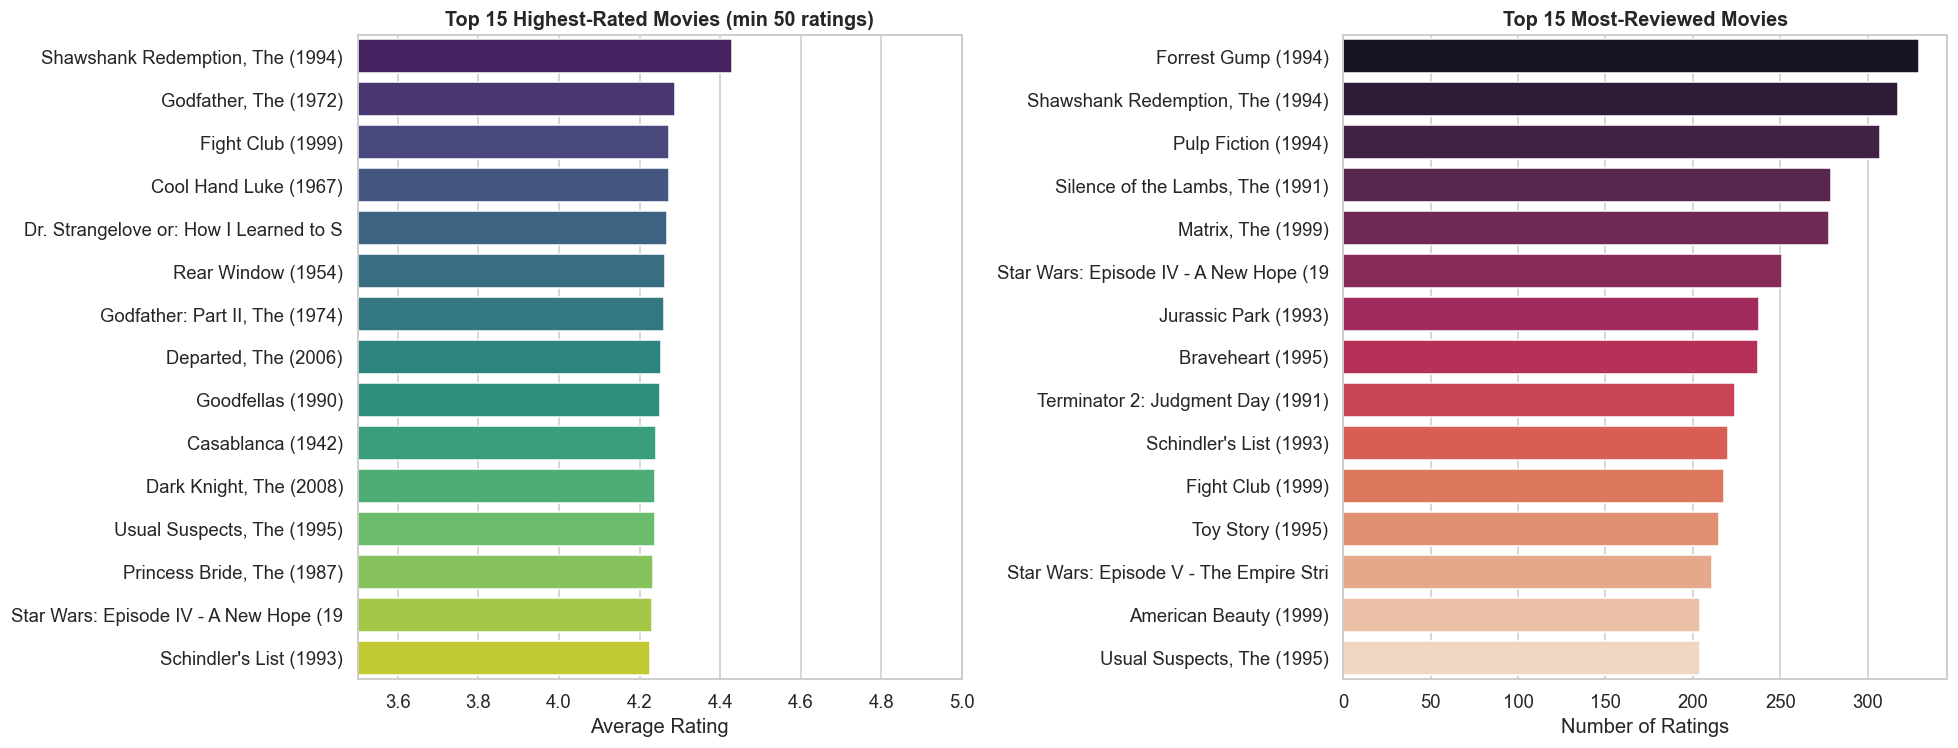

Saved: chart_02_top_movies.png


In [109]:
# Require ≥ 50 ratings for a stable average
MIN_RATINGS = 50

top_rated_pd = to_pandas(
    movie_stats
    .filter(F.col('num_ratings') >= MIN_RATINGS)
    .orderBy(F.desc('avg_rating'))
    .select('title', 'avg_rating', 'num_ratings')
    .limit(15)
)

most_popular_pd = to_pandas(
    movie_stats
    .orderBy(F.desc('num_ratings'))
    .select('title', 'avg_rating', 'num_ratings')
    .limit(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

top_rated_pd['short_title']    = top_rated_pd['title'].str[:38]
most_popular_pd['short_title'] = most_popular_pd['title'].str[:38]

sns.barplot(data=top_rated_pd, y='short_title', x='avg_rating',
            palette='viridis', ax=axes[0], orient='h')
axes[0].set_title(f'Top 15 Highest-Rated Movies (min {MIN_RATINGS} ratings)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('')
axes[0].set_xlim(3.5, 5.0)

sns.barplot(data=most_popular_pd, y='short_title', x='num_ratings',
            palette='rocket', ax=axes[1], orient='h')
axes[1].set_title('Top 15 Most-Reviewed Movies', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout()
plt.savefig('chart_02_top_movies.png', bbox_inches='tight')
plt.show()
print('Saved: chart_02_top_movies.png')

**Observation:** Popularity (number of ratings) does not correlate with quality (average rating). Critically-acclaimed niche films often outscore blockbusters.

### 4.3 User Activity Distribution

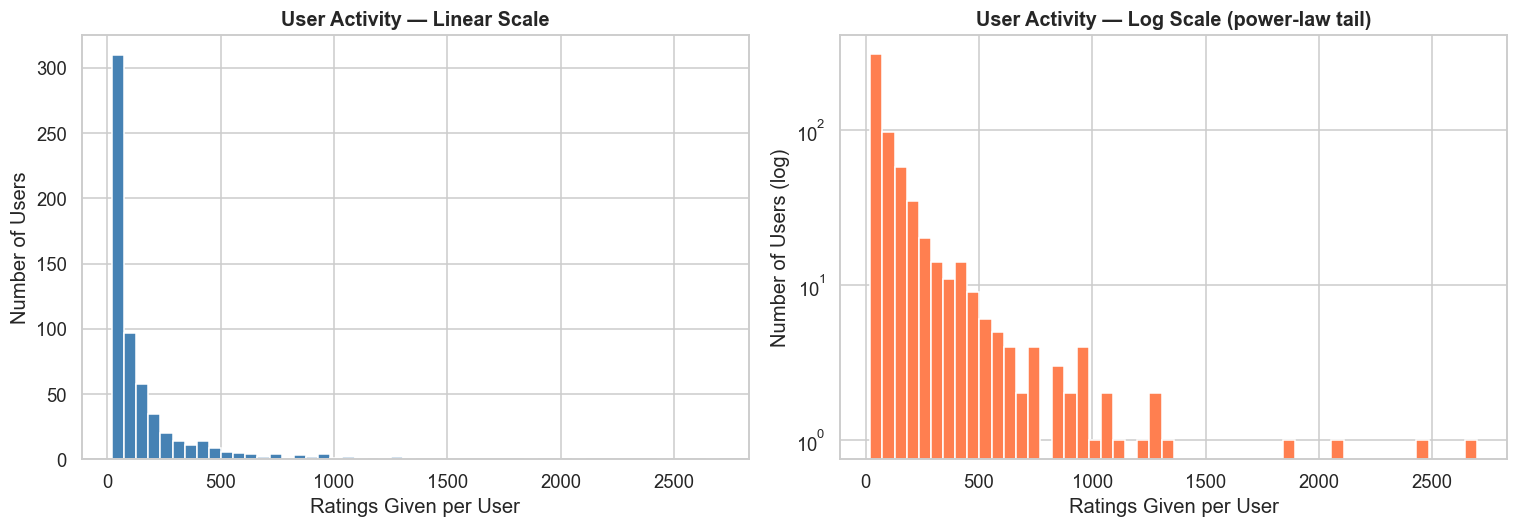

Saved: chart_03_user_activity.png


In [110]:
user_activity_pd = to_pandas(user_stats.select('num_ratings'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(user_activity_pd['num_ratings'], bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('User Activity — Linear Scale', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Ratings Given per User')
axes[0].set_ylabel('Number of Users')

# Log-Y scale reveals the long power-law tail
axes[1].hist(user_activity_pd['num_ratings'], bins=50,
             color='coral', edgecolor='white', log=True)
axes[1].set_title('User Activity — Log Scale (power-law tail)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ratings Given per User')
axes[1].set_ylabel('Number of Users (log)')

plt.tight_layout()
plt.savefig('chart_03_user_activity.png', bbox_inches='tight')
plt.show()
print('Saved: chart_03_user_activity.png')

**Observation:** User activity follows a power-law distribution. The majority of users rate fewer than 50 movies while a small cohort of "power users" rate hundreds — the classic long-tail phenomenon.

### 4.4 Temporal Trends

/var/folders/_9/49lsnmp540lfvlfnj4mg00z80000gn/T/ipykernel_21285/2362623939.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ratings_by_dow, x='day_name', y='num_ratings',


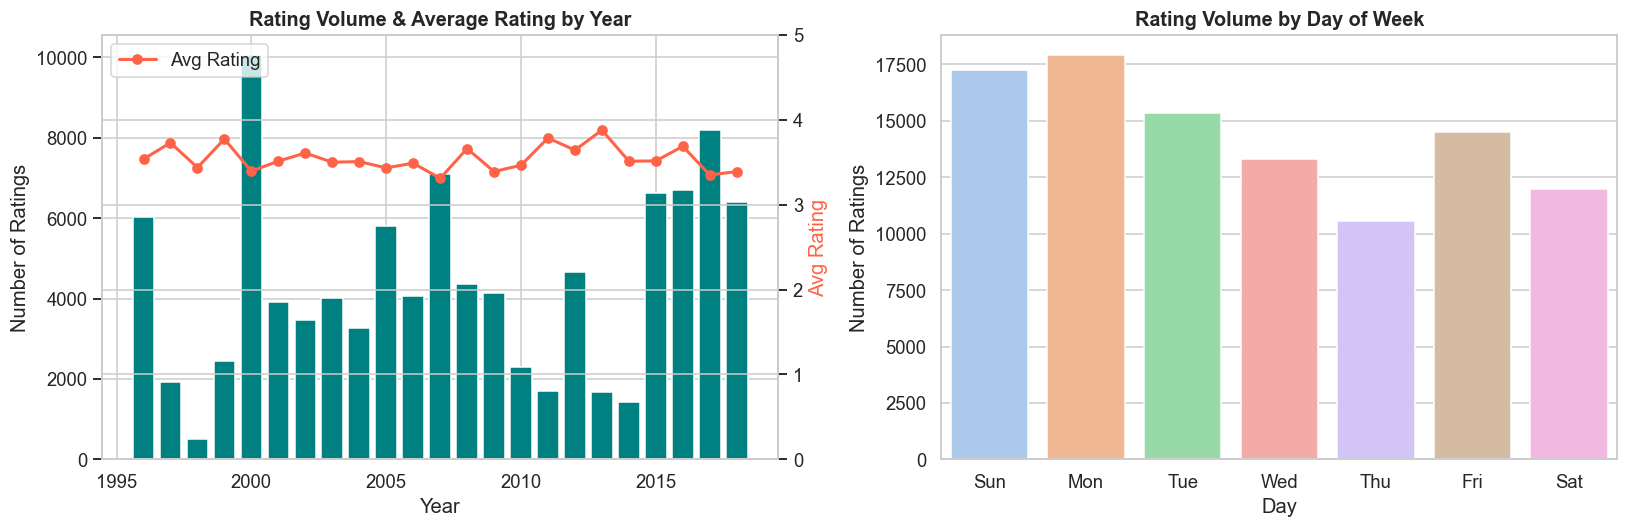

Saved: chart_04_temporal_trends.png


In [111]:
ratings_by_year = to_pandas(
    ratings
    .filter(F.col('year').isNotNull())
    .groupBy('year')
    .agg(
        F.count('rating')           .alias('num_ratings'),
        F.round(F.avg('rating'), 3) .alias('avg_rating'),
    )
    .orderBy('year')
)

day_labels = {1:'Sun', 2:'Mon', 3:'Tue', 4:'Wed', 5:'Thu', 6:'Fri', 7:'Sat'}
ratings_by_dow = to_pandas(
    ratings
    .groupBy('day_of_week').agg(F.count('rating').alias('num_ratings'))
    .orderBy('day_of_week')
)
ratings_by_dow['day_name'] = ratings_by_dow['day_of_week'].map(day_labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Year-over-year volume with average rating overlay
bar_color = 'teal'
axes[0].bar(ratings_by_year['year'], ratings_by_year['num_ratings'],
            color=bar_color, edgecolor='white', label='# Ratings')
ax_twin = axes[0].twinx()
ax_twin.plot(ratings_by_year['year'], ratings_by_year['avg_rating'],
             color='tomato', marker='o', linewidth=2, label='Avg Rating')
ax_twin.set_ylim(0, 5)
ax_twin.set_ylabel('Avg Rating', color='tomato')
axes[0].set_title('Rating Volume & Average Rating by Year',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Ratings')
ax_twin.legend(loc='upper left')

# Day-of-week engagement pattern
day_order = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
sns.barplot(data=ratings_by_dow, x='day_name', y='num_ratings',
            palette='pastel', ax=axes[1], order=day_order)
axes[1].set_title('Rating Volume by Day of Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Ratings')

plt.tight_layout()
plt.savefig('chart_04_temporal_trends.png', bbox_inches='tight')
plt.show()
print('Saved: chart_04_temporal_trends.png')

### 4.5 Genre Analysis

/var/folders/_9/49lsnmp540lfvlfnj4mg00z80000gn/T/ipykernel_21285/543869570.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=genre_stats_pd, y='genre', x='num_ratings',
/var/folders/_9/49lsnmp540lfvlfnj4mg00z80000gn/T/ipykernel_21285/543869570.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


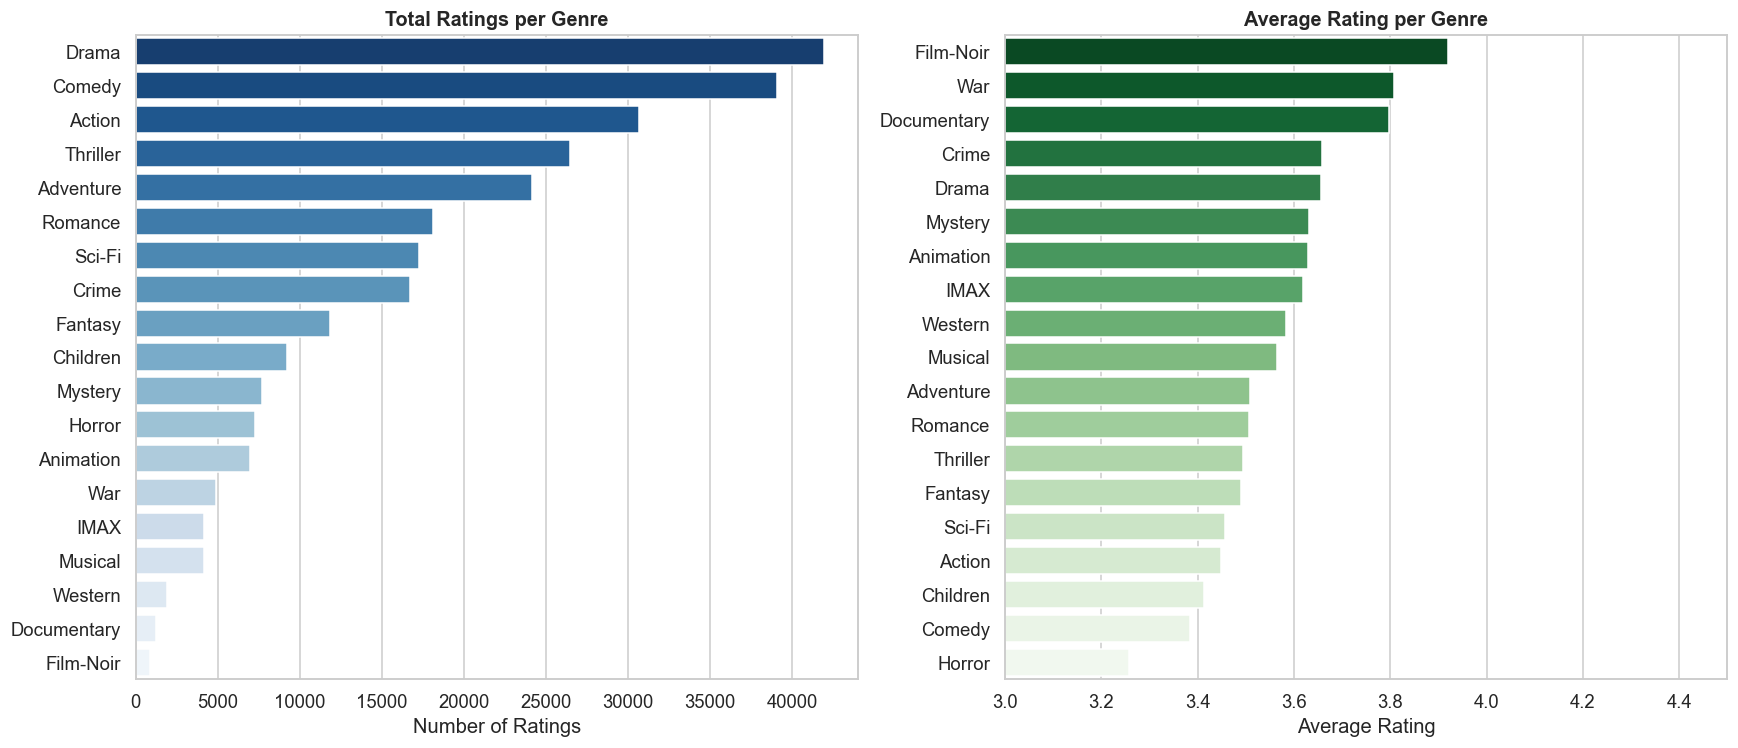

Saved: chart_05_genre_analysis.png


In [112]:
# Explode the pipe-separated genre string into individual rows
genre_ratings = (
    ratings
    .join(movies_raw.select('movieId', 'genres'), on='movieId', how='inner')
    .withColumn('genre', F.explode(F.split(F.col('genres'), '\\|')))
    .filter(F.col('genre') != '(no genres listed)')
)

genre_stats_pd = to_pandas(
    genre_ratings.groupBy('genre')
    .agg(
        F.count('rating')           .alias('num_ratings'),
        F.round(F.avg('rating'), 3) .alias('avg_rating'),
    )
    .orderBy(F.desc('num_ratings'))
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=genre_stats_pd, y='genre', x='num_ratings',
            palette='Blues_r', ax=axes[0], orient='h')
axes[0].set_title('Total Ratings per Genre', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('')

sns.barplot(
    data=genre_stats_pd.sort_values('avg_rating', ascending=False),
    y='genre', x='avg_rating',
    palette='Greens_r', ax=axes[1], orient='h'
)
axes[1].set_title('Average Rating per Genre', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('')
axes[1].set_xlim(3.0, 4.5)

plt.tight_layout()
plt.savefig('chart_05_genre_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: chart_05_genre_analysis.png')

---
## 5. Insights <a id='5'></a>

In [113]:
global_avg   = ratings.agg(F.avg('rating')).collect()[0][0]
power_users  = user_stats.filter(F.col('num_ratings') >= 100).count()
total_users  = user_stats.count()
top_genre    = (
    genre_ratings.groupBy('genre').count()
    .orderBy(F.desc('count')).first()['genre']
)
best_genre   = (
    genre_ratings.groupBy('genre')
    .agg(F.avg('rating').alias('avg_rating'))
    .orderBy(F.desc('avg_rating')).first()['genre']
)

print('=' * 65)
print('  K E Y   I N S I G H T S')
print('=' * 65)
print(f"""
1. RATING SKEW
   Global average rating = {global_avg:.2f}/5.0. The distribution is
   left-skewed: users tend to rate items they enjoyed, creating
   a selection bias towards higher values.

2. POPULARITY vs QUALITY
   The most-reviewed movies (blockbusters) are not the highest-
   rated. Cult films with a smaller but devoted audience consistently
   outscore mass-market titles.

3. POWER-USER CONCENTRATION
   {power_users:,} users ({power_users/total_users:.1%} of all users) have each given
   100+ ratings. This small cohort drives recommendation accuracy
   and disproportionately shapes aggregate statistics.

4. LONG-TAIL / SPARSITY CHALLENGE
   Activity follows a power-law: most users rate very few items.
   The resulting sparse matrix (>98% empty) is the core challenge
   for collaborative filtering algorithms like ALS.

5. GENRE VOLUME vs GENRE QUALITY
   '{top_genre}' leads in total interaction volume, but
   '{best_genre}' earns the highest average rating — serving
   a niche but highly engaged audience segment.

6. TEMPORAL ENGAGEMENT
   Rating activity peaks on weekends (Fri–Sun), consistent with
   leisure-time media consumption. This cadence can inform
   cold-start heuristics and personalised notification scheduling.
""")
print('=' * 65)

  K E Y   I N S I G H T S

1. RATING SKEW
   Global average rating = 3.50/5.0. The distribution is
   left-skewed: users tend to rate items they enjoyed, creating
   a selection bias towards higher values.

2. POPULARITY vs QUALITY
   The most-reviewed movies (blockbusters) are not the highest-
   rated. Cult films with a smaller but devoted audience consistently
   outscore mass-market titles.

3. POWER-USER CONCENTRATION
   248 users (40.7% of all users) have each given
   100+ ratings. This small cohort drives recommendation accuracy
   and disproportionately shapes aggregate statistics.

4. LONG-TAIL / SPARSITY CHALLENGE
   Activity follows a power-law: most users rate very few items.
   The resulting sparse matrix (>98% empty) is the core challenge
   for collaborative filtering algorithms like ALS.

5. GENRE VOLUME vs GENRE QUALITY
   'Drama' leads in total interaction volume, but
   'Film-Noir' earns the highest average rating — serving
   a niche but highly engaged audience seg

---
## 6. Recommendation Model (ALS) <a id='6'></a>

**Alternating Least Squares (ALS)** decomposes the sparse user-item rating matrix **R** into
two low-rank matrices **U** (user factors) and **V** (item factors), such that **U × Vᵀ ≈ R**.
It alternates between:
1. Fixing **V** → solve for each row of **U** (ordinary least squares)
2. Fixing **U** → solve for each row of **V** (ordinary least squares)

This is embarrassingly parallel, making ALS highly scalable in Spark.

### 6.1 Prepare Data Splits

In [114]:
# Select only the three columns ALS requires
als_data = ratings.select(
    F.col('userId') .cast(IntegerType()),
    F.col('movieId').cast(IntegerType()),
    F.col('rating') .cast(FloatType()),
)

# Reproducible 80/20 stratified-ish split
train_df, test_df = als_data.randomSplit([0.8, 0.2], seed=42)

# Cache both — ALS iterates over training data many times
train_df.cache()
test_df.cache()

print(f'Training rows : {train_df.count():,}')
print(f'Test rows     : {test_df.count():,}')

Training rows : 80,794
Test rows     : 20,042


### 6.2 Build & Train Baseline ALS Model

In [115]:
als = ALS(
    userCol           = 'userId',
    itemCol           = 'movieId',
    ratingCol         = 'rating',
    rank              = 10,    # latent factor dimensionality
    maxIter           = 10,    # ALS iteration count
    regParam          = 0.1,   # L2 regularisation strength
    coldStartStrategy = 'drop',# drop NaN predictions for unseen users/items
    nonnegative       = False, # allow negative factors
    implicitPrefs     = False, # explicit star ratings
    seed              = 42,
)

print('Training baseline ALS model ...')
model_baseline = als.fit(train_df)
print('Baseline model trained.')

Training baseline ALS model ...
Baseline model trained.


---
## 7. Evaluation & Parameter Tuning <a id='7'></a>

### 7.1 Baseline RMSE

In [116]:
evaluator = RegressionEvaluator(
    metricName    = 'rmse',
    labelCol      = 'rating',
    predictionCol = 'prediction',
)

baseline_preds = model_baseline.transform(test_df)
rmse_baseline  = evaluator.evaluate(baseline_preds)

print(f'Baseline RMSE  : {rmse_baseline:.4f}')
print(f'(rank=10, regParam=0.1, maxIter=10)')

Baseline RMSE  : 0.8802
(rank=10, regParam=0.1, maxIter=10)


### 7.2 Hyperparameter Tuning via Cross-Validation

In [117]:
# Build search grid — kept small to stay tractable on a single machine
param_grid = (
    ParamGridBuilder()
    .addGrid(als.rank,     [10, 20])
    .addGrid(als.regParam, [0.05, 0.1, 0.2])
    .addGrid(als.maxIter,  [10])
    .build()
)

cv = CrossValidator(
    estimator          = als,
    estimatorParamMaps = param_grid,
    evaluator          = evaluator,
    numFolds           = 3,
    seed               = 42,
    parallelism        = 2,
)

print(f'Running {len(param_grid)} combinations x 3-fold CV ...')
cv_model   = cv.fit(train_df)
best_model = cv_model.bestModel
rmse_best  = evaluator.evaluate(best_model.transform(test_df))

print(f'\nBest rank     : {best_model.rank}')
print(f'Best regParam : {best_model._java_obj.parent().getRegParam()}')
print(f'Best RMSE     : {rmse_best:.4f}')
print(f'Improvement   : {rmse_baseline - rmse_best:+.4f} vs baseline')

Running 6 combinations x 3-fold CV ...

Best rank     : 10
Best regParam : 0.2
Best RMSE     : 0.8773
Improvement   : +0.0030 vs baseline


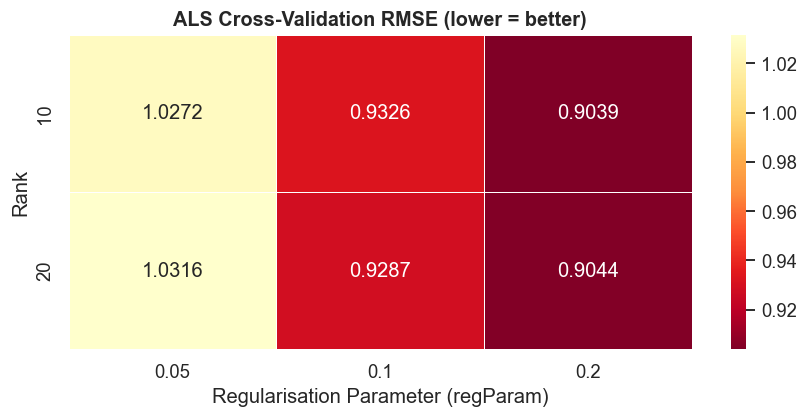

Saved: chart_06_cv_heatmap.png


In [118]:
# ── Visualise CV results as a heatmap ─────────────────────────────────────────
ranks      = [10, 20]
reg_params = [0.05, 0.1, 0.2]

results = [
    {'rank': rank, 'regParam': reg, 'RMSE': rmse}
    for (rank, reg), rmse in zip(
        itertools.product(ranks, reg_params), cv_model.avgMetrics
    )
]
pivot = pd.DataFrame(results).pivot(index='rank', columns='regParam', values='RMSE')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd_r',
            linewidths=0.5, ax=ax)
ax.set_title('ALS Cross-Validation RMSE (lower = better)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Regularisation Parameter (regParam)')
ax.set_ylabel('Rank')
plt.tight_layout()
plt.savefig('chart_06_cv_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: chart_06_cv_heatmap.png')

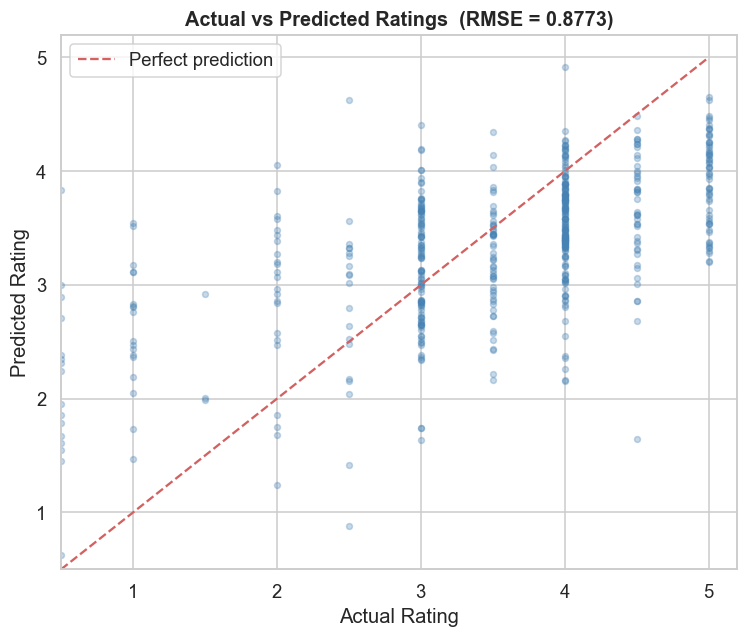

Saved: chart_07_actual_vs_predicted.png


In [119]:
# ── Actual vs Predicted scatter (best model) ──────────────────────────────────
sample_preds = (
    best_model.transform(test_df)
    .dropna(subset=['prediction'])
    .limit(500)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample_preds['rating'], sample_preds['prediction'],
           alpha=0.3, s=15, color='steelblue')
ax.plot([0.5, 5], [0.5, 5], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlim(0.5, 5.2)
ax.set_ylim(0.5, 5.2)
ax.set_xlabel('Actual Rating')
ax.set_ylabel('Predicted Rating')
ax.set_title(f'Actual vs Predicted Ratings  (RMSE = {rmse_best:.4f})',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('chart_07_actual_vs_predicted.png', bbox_inches='tight')
plt.show()
print('Saved: chart_07_actual_vs_predicted.png')

**Observation:** Predictions cluster around the true rating range (1–5). Outliers appear mainly at the extremes (very low or very high actual ratings), which is typical of matrix-factorisation models.

---
## 8. Recommendations Output <a id='8'></a>

### 8.1 Top-N Recommendations for a Single User

In [120]:
TARGET_USER = 1
TOP_N       = 10

user_recs = (
    best_model
    .recommendForUserSubset(
        spark.createDataFrame([(TARGET_USER,)], ['userId']),
        numItems=TOP_N
    )
    # recommendations column is an array of (movieId, rating) structs
    .withColumn('rec', F.explode('recommendations'))
    .select(
        'userId',
        F.col('rec.movieId')             .alias('movieId'),
        F.round(F.col('rec.rating'), 4)  .alias('predicted_rating'),
    )
    .join(movies_raw.select('movieId', 'title', 'genres'), on='movieId', how='left')
    .orderBy(F.desc('predicted_rating'))
)

print(f'Top {TOP_N} recommendations for User {TARGET_USER}:')
user_recs.show(TOP_N, truncate=False)

Top 10 recommendations for User 1:
+-------+------+----------------+-----------------------------------------------+--------------------+
|movieId|userId|predicted_rating|title                                          |genres              |
+-------+------+----------------+-----------------------------------------------+--------------------+
|3379   |1     |6.0057          |On the Beach (1959)                            |Drama               |
|132333 |1     |5.9615          |Seve (2014)                                    |Documentary|Drama   |
|5915   |1     |5.9615          |Victory (a.k.a. Escape to Victory) (1981)      |Action|Drama|War    |
|5490   |1     |5.9615          |The Big Bus (1976)                             |Action|Comedy       |
|25947  |1     |5.8521          |Unfaithfully Yours (1948)                      |Comedy              |
|92494  |1     |5.7939          |Dylan Moran: Monster (2004)                    |Comedy|Documentary  |
|33649  |1     |5.7756          |Savin

### 8.2 Top-5 Recommendations for Every User

In [121]:
all_user_recs = (
    best_model.recommendForAllUsers(5)
    .withColumn('rec', F.explode('recommendations'))
    .select(
        'userId',
        F.col('rec.movieId')            .alias('movieId'),
        F.round(F.col('rec.rating'), 4) .alias('predicted_rating'),
    )
    .join(movies_raw.select('movieId', 'title'), on='movieId', how='left')
)

print(f'Total recommendation rows : {all_user_recs.count():,}')
print('Sample (first 20 rows, ordered by user then predicted rating):')
all_user_recs.orderBy('userId', F.desc('predicted_rating')).show(20, truncate=False)

Total recommendation rows : 3,050
Sample (first 20 rows, ordered by user then predicted rating):
+-------+------+----------------+----------------------------------------------------+
|movieId|userId|predicted_rating|title                                               |
+-------+------+----------------+----------------------------------------------------+
|3379   |1     |6.0057          |On the Beach (1959)                                 |
|132333 |1     |5.9615          |Seve (2014)                                         |
|5915   |1     |5.9615          |Victory (a.k.a. Escape to Victory) (1981)           |
|5490   |1     |5.9615          |The Big Bus (1976)                                  |
|25947  |1     |5.8521          |Unfaithfully Yours (1948)                           |
|131724 |2     |4.7241          |The Jinx: The Life and Deaths of Robert Durst (2015)|
|141718 |2     |4.7144          |Deathgasm (2015)                                    |
|3379   |2     |4.7139          |

### 8.3 Globally Most-Recommended Items

Top 20 globally recommended movies:
+-------+-------------------------------------------------------+----------------------+--------------------+
|movieId|title                                                  |recommended_to_n_users|avg_predicted_rating|
+-------+-------------------------------------------------------+----------------------+--------------------+
|3379   |On the Beach (1959)                                    |484                   |5.0554              |
|33649  |Saving Face (2004)                                     |364                   |4.954               |
|60943  |Frozen River (2008)                                    |232                   |4.9562              |
|67618  |Strictly Sexual (2008)                                 |228                   |5.0846              |
|59018  |Visitor, The (2007)                                    |192                   |4.9384              |
|132333 |Seve (2014)                                            |176                

/var/folders/_9/49lsnmp540lfvlfnj4mg00z80000gn/T/ipykernel_21285/2224861006.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=global_top_pd, y='short_title', x='recommended_to_n_users',


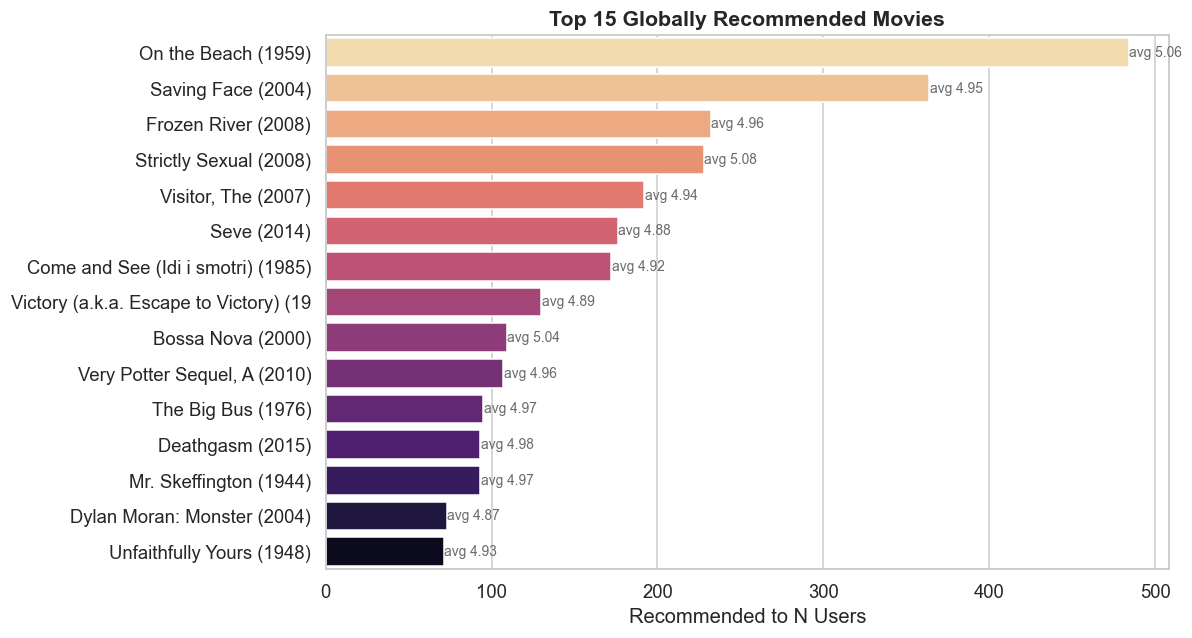

Saved: chart_08_global_recommendations.png


In [122]:
# Aggregate by movie: how many users received each recommendation?
global_top = (
    all_user_recs
    .groupBy('movieId', 'title')
    .agg(
        F.count('userId')                  .alias('recommended_to_n_users'),
        F.round(F.avg('predicted_rating'), 4).alias('avg_predicted_rating'),
    )
    .orderBy(F.desc('recommended_to_n_users'), F.desc('avg_predicted_rating'))
)

print('Top 20 globally recommended movies:')
global_top.show(20, truncate=False)

# Visualise
global_top_pd = to_pandas(global_top.limit(15))
global_top_pd['short_title'] = global_top_pd['title'].str[:38]

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=global_top_pd, y='short_title', x='recommended_to_n_users',
            palette='magma_r', ax=ax, orient='h')

# Annotate the average predicted rating on each bar
for idx, row in global_top_pd.iterrows():
    ax.text(
        row['recommended_to_n_users'] + 0.3, idx,
        f"avg {row['avg_predicted_rating']:.2f}",
        va='center', fontsize=9, color='dimgrey'
    )

ax.set_title('Top 15 Globally Recommended Movies', fontsize=14, fontweight='bold')
ax.set_xlabel('Recommended to N Users')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('chart_08_global_recommendations.png', bbox_inches='tight')
plt.show()
print('Saved: chart_08_global_recommendations.png')

---
## 9. Cold-Start Problem & Mitigation Strategies <a id='9'></a>

### The Cold-Start Problem

**Cold-start** occurs when the ALS model cannot generate recommendations for a user
because they have **no rating history** in the training data.

This is a common real-world limitation of collaborative filtering.
We address it with **four progressive strategies**:

| # | Strategy | Requires from User | Technical Basis |
|---|---|---|---|
| 1 | **Popularity Fallback** | Nothing | L2-norm of ALS item factor vectors |
| 2 | **Content-Based Genre Filter** | Preferred genres | Popularity filtered by genre |
| 3 | **Item-Item Similarity** | One liked movie | Cosine similarity on ALS item factors |
| 4 | **Onboarding (Mini Rating)** | Rate 3–10 movies | Weighted average of item factors → user proxy vector |


In [123]:
# ── Load pre-trained ALS model for cold-start demos ──────────────────────────
from pyspark.ml.recommendation import ALSModel
import numpy as np

MODEL_PATH     = 'models/als_model'
METADATA_PATH  = 'models/movies_metadata.parquet'

# Load model and movie metadata
best_model_cs  = ALSModel.load(MODEL_PATH)
movies_cs      = spark.read.parquet(METADATA_PATH).toPandas()

print(f'Model loaded — {len(movies_cs):,} movies in metadata')

# ── Extract ALS item factor matrix ────────────────────────────────────────────
item_factors_spark = best_model_cs.itemFactors
item_factors_pd    = item_factors_spark.toPandas()

k          = len(item_factors_pd['features'].iloc[0])
feat_cols  = [f'f{i}' for i in range(k)]
feat_mat   = pd.DataFrame(item_factors_pd['features'].tolist(), columns=feat_cols)
feat_mat['movieId'] = item_factors_pd['id'].values
item_factors_df     = feat_mat[['movieId'] + feat_cols]

print(f'Item factor matrix shape : {item_factors_df.shape}  (movies × rank={k})')


Model loaded — 9,742 movies in metadata
Item factor matrix shape : (8990, 11)  (movies × rank=10)


### 9.1 Strategy 1 — Popularity Fallback

Use the **L2-norm of each movie's ALS item factor vector** as a proxy popularity score.
Movies with higher norms are generally more distinctive in the latent factor space and
tend to be well-rated. Normalised to [0, 5].


In [124]:
# ── Compute L2-norm popularity score ─────────────────────────────────────────
norms    = np.linalg.norm(feat_mat[feat_cols].values, axis=1)
norm_df  = pd.DataFrame({'movieId': feat_mat['movieId'].values, 'score': norms})
max_norm = norm_df['score'].max()
norm_df['score'] = norm_df['score'] / max_norm * 5.0

popularity_stats = (
    norm_df
    .merge(movies_cs[['movieId','title','genres']], on='movieId', how='inner')
    .sort_values('score', ascending=False)
)

top_popular = popularity_stats.head(15)
print('Top-15 Popular Movies (by ALS item factor norm):')
print(top_popular[['title','genres','score']].to_string(index=False))


Top-15 Popular Movies (by ALS item factor norm):
                                                  title                          genres    score
                                         Troll 2 (1990)                  Fantasy|Horror 5.000000
                                         Holiday (1938)            Comedy|Drama|Romance 4.908217
                            Truly, Madly, Deeply (1991)                   Drama|Romance 4.690638
                                      The Artist (2011)            Comedy|Drama|Romance 4.655783
                                  The Handmaiden (2016)          Drama|Romance|Thriller 4.518552
                                  Black Dynamite (2009)                   Action|Comedy 4.504000
Match Factory Girl, The (Tulitikkutehtaan tyttö) (1990)                    Comedy|Drama 4.467535
                                      Bossa Nova (2000)            Comedy|Drama|Romance 4.414144
                                     Melancholia (2011)                    Dra

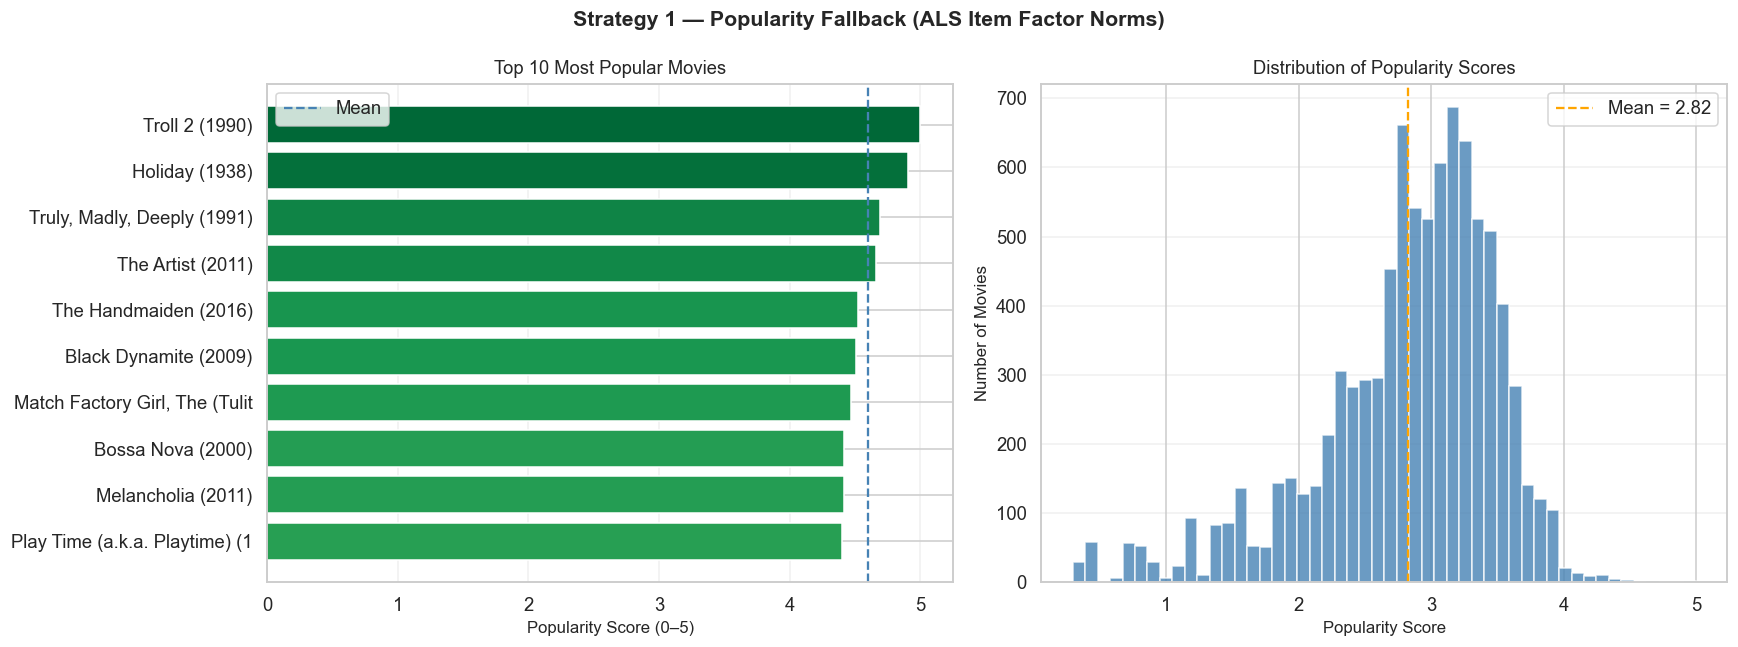

Saved → docs/vis_cold_start_popularity.png


In [125]:
# ── Visualise popularity scores ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Strategy 1 — Popularity Fallback (ALS Item Factor Norms)', fontsize=14, fontweight='bold')

# Bar chart: top 15
top10 = top_popular.head(10)
axes[0].barh(
    top10['title'].str[:30].values[::-1],
    top10['score'].values[::-1],
    color=plt.cm.RdYlGn(top10['score'].values[::-1] / 5.0)
)
axes[0].set_xlabel('Popularity Score (0–5)', fontsize=11)
axes[0].set_title('Top 10 Most Popular Movies', fontsize=12)
axes[0].axvline(top10['score'].mean(), color='steelblue', linestyle='--', label='Mean')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Histogram: score distribution
axes[1].hist(popularity_stats['score'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Popularity Score', fontsize=11)
axes[1].set_ylabel('Number of Movies', fontsize=11)
axes[1].set_title('Distribution of Popularity Scores', fontsize=12)
axes[1].axvline(popularity_stats['score'].mean(), color='orange', linestyle='--',
                label=f"Mean = {popularity_stats['score'].mean():.2f}")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('docs/vis_cold_start_popularity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → docs/vis_cold_start_popularity.png')


### 9.2 Strategy 2 — Content-Based Genre Filter

Filter movies by **user-supplied genre preferences**, then rank by popularity score.
This provides meaningful recommendations as soon as the user specifies what they like.


In [126]:
# ── Genre filter + ranking ────────────────────────────────────────────────────
def recommend_by_genre(genres: list, n: int = 10) -> pd.DataFrame:
    """Filter movies by genre then rank by ALS popularity score."""
    mask    = movies_cs['genres'].str.contains('|'.join(genres), case=False, na=False)
    filtered = movies_cs[mask].copy()
    merged  = (
        filtered.merge(popularity_stats[['movieId','score']], on='movieId', how='left')
        .fillna({'score': 0.0})
        .sort_values('score', ascending=False)
    )
    return merged[['movieId','title','genres','score']].head(n)

# Example: user likes Action + Sci-Fi
user_genres   = ['Action', 'Sci-Fi']
genre_results = recommend_by_genre(user_genres, n=10)

print(f'Content-Based recommendations for genres: {user_genres}')
print(genre_results.to_string(index=False))


Content-Based recommendations for genres: ['Action', 'Sci-Fi']
 movieId                                                                                                                         title                                genres    score
   72171                                                                                                         Black Dynamite (2009)                         Action|Comedy 4.504000
   86320                                                                                                            Melancholia (2011)                          Drama|Sci-Fi 4.414070
    8477                                                                                                              Jetée, La (1962)                        Romance|Sci-Fi 4.379044
    7700                                                                            Wages of Fear, The (Salaire de la peur, Le) (1953)       Action|Adventure|Drama|Thriller 4.313890
   96004 Dragon Ball Z: The

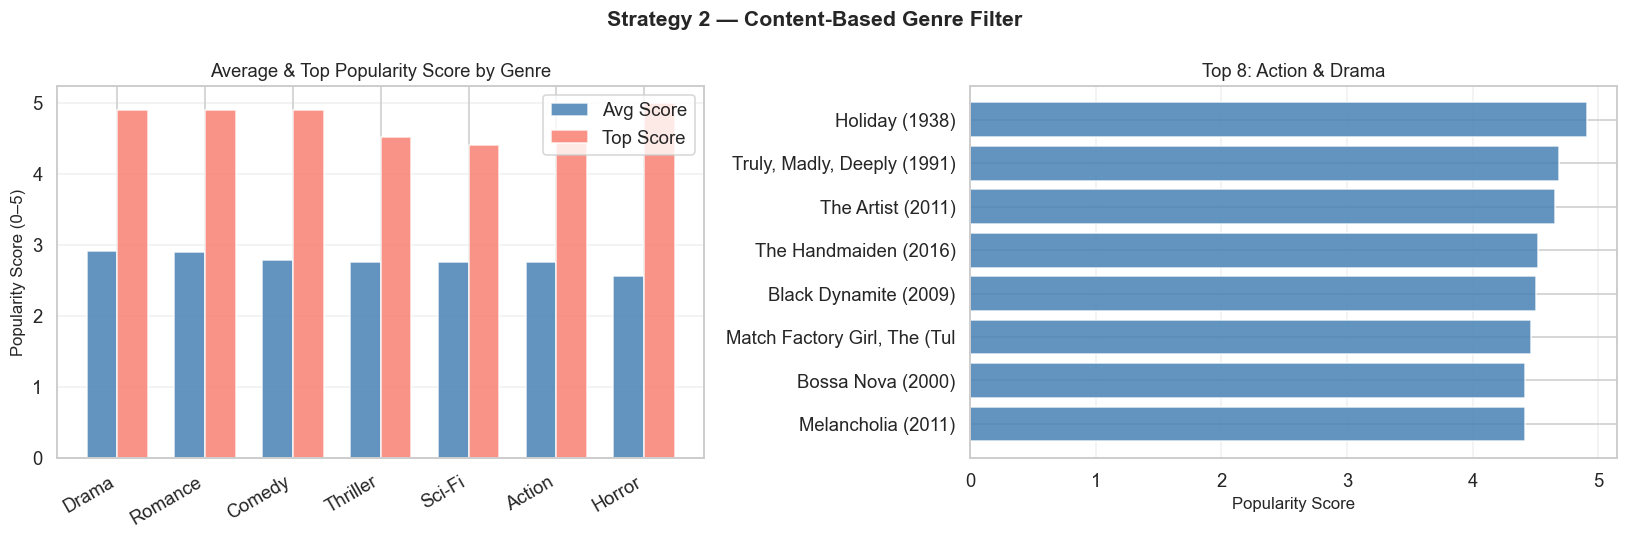

Saved → docs/vis_cold_start_genre.png


In [127]:
# ── Visualise: compare genre-filtered vs global popularity ──────────────────
genre_list = ['Drama', 'Comedy', 'Action', 'Sci-Fi', 'Horror', 'Romance', 'Thriller']
genre_counts = []
for g in genre_list:
    mask = movies_cs['genres'].str.contains(g, case=False, na=False)
    merged_g = movies_cs[mask].merge(popularity_stats[['movieId','score']], on='movieId', how='left')
    genre_counts.append({
        'genre': g,
        'n_movies': mask.sum(),
        'avg_score': merged_g['score'].mean(),
        'top_score': merged_g['score'].max()
    })
genre_comp_df = pd.DataFrame(genre_counts).sort_values('avg_score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Strategy 2 — Content-Based Genre Filter', fontsize=14, fontweight='bold')

x = np.arange(len(genre_comp_df))
w = 0.35
axes[0].bar(x - w/2, genre_comp_df['avg_score'], w, label='Avg Score', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, genre_comp_df['top_score'],  w, label='Top Score', color='salmon',   alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(genre_comp_df['genre'], rotation=30, ha='right')
axes[0].set_ylabel('Popularity Score (0–5)', fontsize=11)
axes[0].set_title('Average & Top Popularity Score by Genre', fontsize=12)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

top_action_drama = recommend_by_genre(['Action','Drama'], n=8)
axes[1].barh(top_action_drama['title'].str[:28].values[::-1],
             top_action_drama['score'].values[::-1],
             color='steelblue', alpha=0.85)
axes[1].set_xlabel('Popularity Score', fontsize=11)
axes[1].set_title('Top 8: Action & Drama', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('docs/vis_cold_start_genre.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → docs/vis_cold_start_genre.png')


### 9.3 Strategy 3 — Item-Item Similarity (ALS Item Factors)

Given one movie the user likes, find the **most similar movies** by computing
**cosine similarity** between ALS item factor vectors.

This exploits the rich latent-factor structure learned by ALS — similar movies
occupy nearby positions in the factor space.


In [128]:
# ── Cosine similarity on ALS item factors ────────────────────────────────────
def find_similar_movies(seed_movie_id: int, n: int = 10) -> pd.DataFrame:
    """Return top-n movies most similar to seed_movie_id via cosine similarity."""
    factors  = item_factors_df
    seed_row = factors[factors['movieId'] == seed_movie_id]
    if seed_row.empty:
        raise ValueError(f'movie_id {seed_movie_id} not found in item factors')
    seed_vec  = seed_row[feat_cols].values[0]
    all_vecs  = factors[feat_cols].values
    seed_norm = np.linalg.norm(seed_vec)
    all_norms = np.linalg.norm(all_vecs, axis=1)
    denom     = seed_norm * all_norms
    denom     = np.where(denom == 0, 1e-9, denom)
    sims      = all_vecs.dot(seed_vec) / denom
    sim_df    = pd.DataFrame({'movieId': factors['movieId'].values, 'similarity': sims})
    sim_df    = sim_df[sim_df['movieId'] != seed_movie_id]
    top       = sim_df.nlargest(n, 'similarity')
    return top.merge(movies_cs[['movieId','title','genres']], on='movieId', how='left')

# Example: seed = Toy Story (movieId=1)
seed_id    = 1
seed_title = movies_cs[movies_cs['movieId'] == seed_id]['title'].values[0]
similar    = find_similar_movies(seed_id, n=10)

print(f'Movies similar to: "{seed_title}"')
print(similar[['title','genres','similarity']].to_string(index=False))


Movies similar to: "Toy Story (1995)"
                                                                                   title                                genres  similarity
                                                                Replacements, The (2000)                                Comedy    0.984870
                                                                  We Bought a Zoo (2011)                          Comedy|Drama    0.980789
                                                                       Serial Mom (1994)                   Comedy|Crime|Horror    0.979641
                                                                   School of Rock (2003)                        Comedy|Musical    0.978890
                                                                        Airplane! (1980)                                Comedy    0.978701
                                                     No Direction Home: Bob Dylan (2005)                           Documentary  

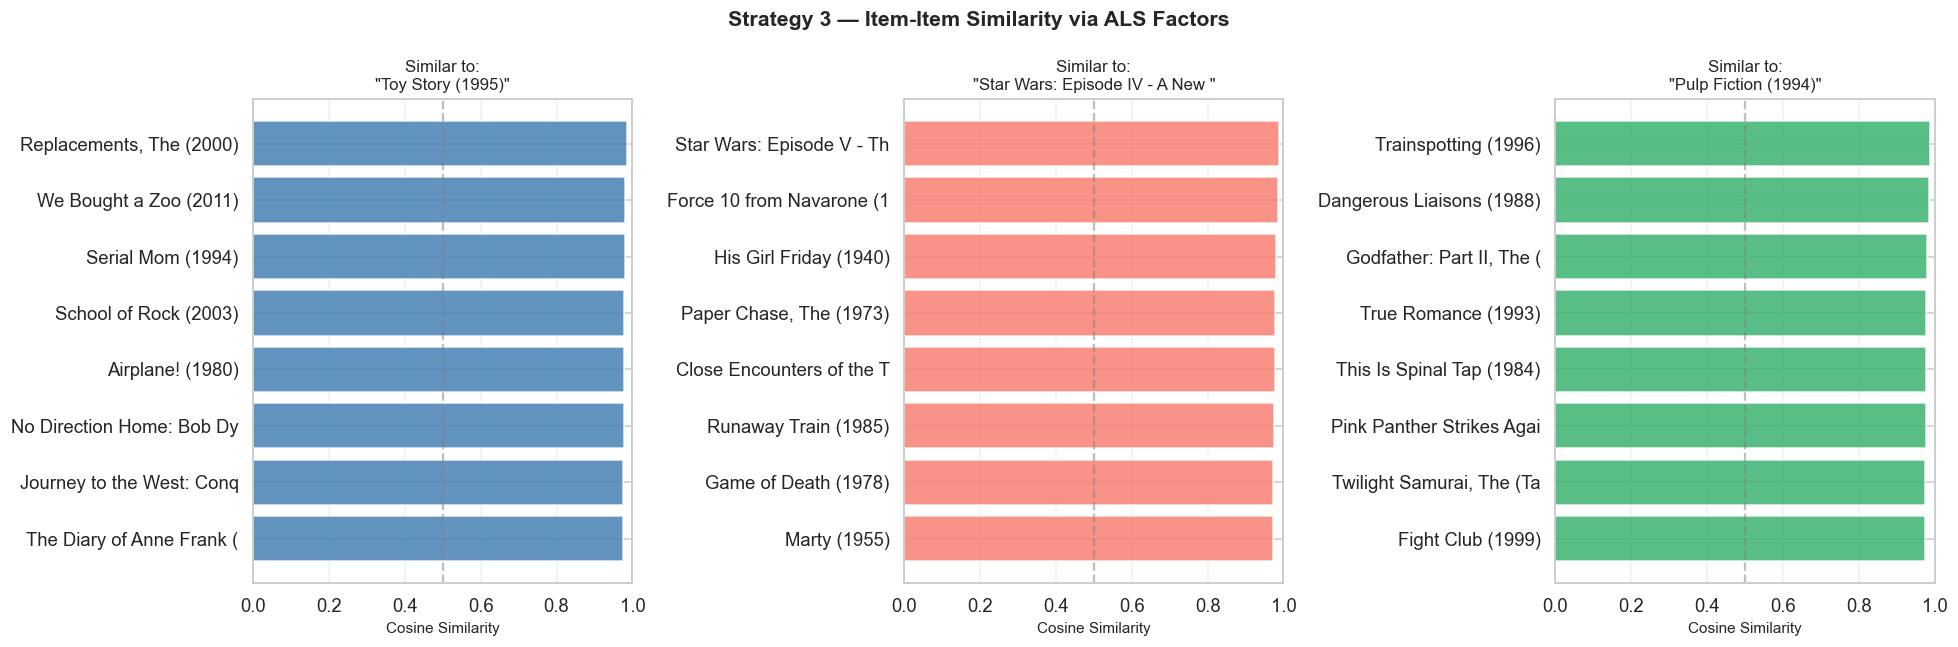

Saved → docs/vis_cold_start_similarity.png


In [129]:
# ── Visualise item-item similarity ────────────────────────────────────────────
seed_ids   = [1, 260, 296]   # Toy Story, Star Wars, Pulp Fiction
seed_names = [movies_cs[movies_cs['movieId']==sid]['title'].values[0][:30] for sid in seed_ids]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Strategy 3 — Item-Item Similarity via ALS Factors', fontsize=14, fontweight='bold')

colors = ['steelblue','salmon','mediumseagreen']
for ax, sid, sname, col in zip(axes, seed_ids, seed_names, colors):
    sim_df_vis = find_similar_movies(sid, n=8)
    ax.barh(sim_df_vis['title'].str[:25].values[::-1],
            sim_df_vis['similarity'].values[::-1],
            color=col, alpha=0.85)
    ax.set_xlabel('Cosine Similarity', fontsize=10)
    ax.set_title(f'Similar to:\n"{sname}"', fontsize=11)
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.3)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 threshold')

plt.tight_layout()
plt.savefig('docs/vis_cold_start_similarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → docs/vis_cold_start_similarity.png')


### 9.4 Strategy 4 — Onboarding (Weighted Factor Averaging)

The user rates **3–10 seed movies** during onboarding.
We approximate their user factor vector as the **rating-weighted average** of those
movies' ALS item factor vectors, then rank all movies by dot-product score.

This is a **stateless**, instant personalisation — no model retraining needed.


In [130]:
# ── Onboarding: infer user vector from seed ratings ──────────────────────────
def onboarding_recommend(seed_ratings: list, n: int = 10) -> pd.DataFrame:
    """
    seed_ratings: [{'movie_id': int, 'rating': float}, ...]
    Returns top-n recommendations using inferred user factor vector.
    """
    factors   = item_factors_df
    rated_ids = {r['movie_id'] for r in seed_ratings}
    user_vec  = np.zeros(len(feat_cols))
    total_w   = 0.0
    for entry in seed_ratings:
        mid = entry['movie_id']
        w   = float(entry.get('rating', 3.5))
        row = factors[factors['movieId'] == mid]
        if row.empty:
            continue
        user_vec += w * row[feat_cols].values[0]
        total_w  += w
    if total_w == 0:
        raise ValueError('None of the seed movie_ids found in item factors')
    user_vec /= total_w
    all_vecs  = factors[feat_cols].values
    scores    = all_vecs.dot(user_vec)
    score_df  = pd.DataFrame({'movieId': factors['movieId'].values, 'predicted_rating': scores})
    score_df  = score_df[~score_df['movieId'].isin(rated_ids)]
    top       = score_df.nlargest(n, 'predicted_rating')
    return top.merge(movies_cs[['movieId','title','genres']], on='movieId', how='left')

# Simulate a new user who rated 5 seed movies
seed_ratings_example = [
    {'movie_id': 1,   'rating': 5.0},   # Toy Story
    {'movie_id': 260, 'rating': 4.5},   # Star Wars: A New Hope
    {'movie_id': 480, 'rating': 4.0},   # Jurassic Park
    {'movie_id': 588, 'rating': 3.5},   # Aladdin
    {'movie_id': 364, 'rating': 5.0},   # The Lion King
]

onboarding_recs = onboarding_recommend(seed_ratings_example, n=10)
print('Onboarding recommendations based on seed ratings:')
for r in seed_ratings_example:
    t = movies_cs[movies_cs['movieId']==r['movie_id']]['title'].values
    print(f"  Seed: {t[0] if len(t) else r['movie_id']} → rating {r['rating']}")
print()
print(onboarding_recs[['title','genres','predicted_rating']].to_string(index=False))


Onboarding recommendations based on seed ratings:
  Seed: Toy Story (1995) → rating 5.0
  Seed: Star Wars: Episode IV - A New Hope (1977) → rating 4.5
  Seed: Jurassic Park (1993) → rating 4.0
  Seed: Aladdin (1992) → rating 3.5
  Seed: Lion King, The (1994) → rating 5.0

                                                 title                     genres  predicted_rating
                                    Saving Face (2004)       Comedy|Drama|Romance          4.972603
                                   On the Beach (1959)                      Drama          4.827313
                               Last Detail, The (1973)               Comedy|Drama          4.789747
                                      Lady Jane (1986)              Drama|Romance          4.662127
                              Crossing Delancey (1988)             Comedy|Romance          4.662127
                                     Adam's Rib (1949)             Comedy|Romance          4.618764
                          T

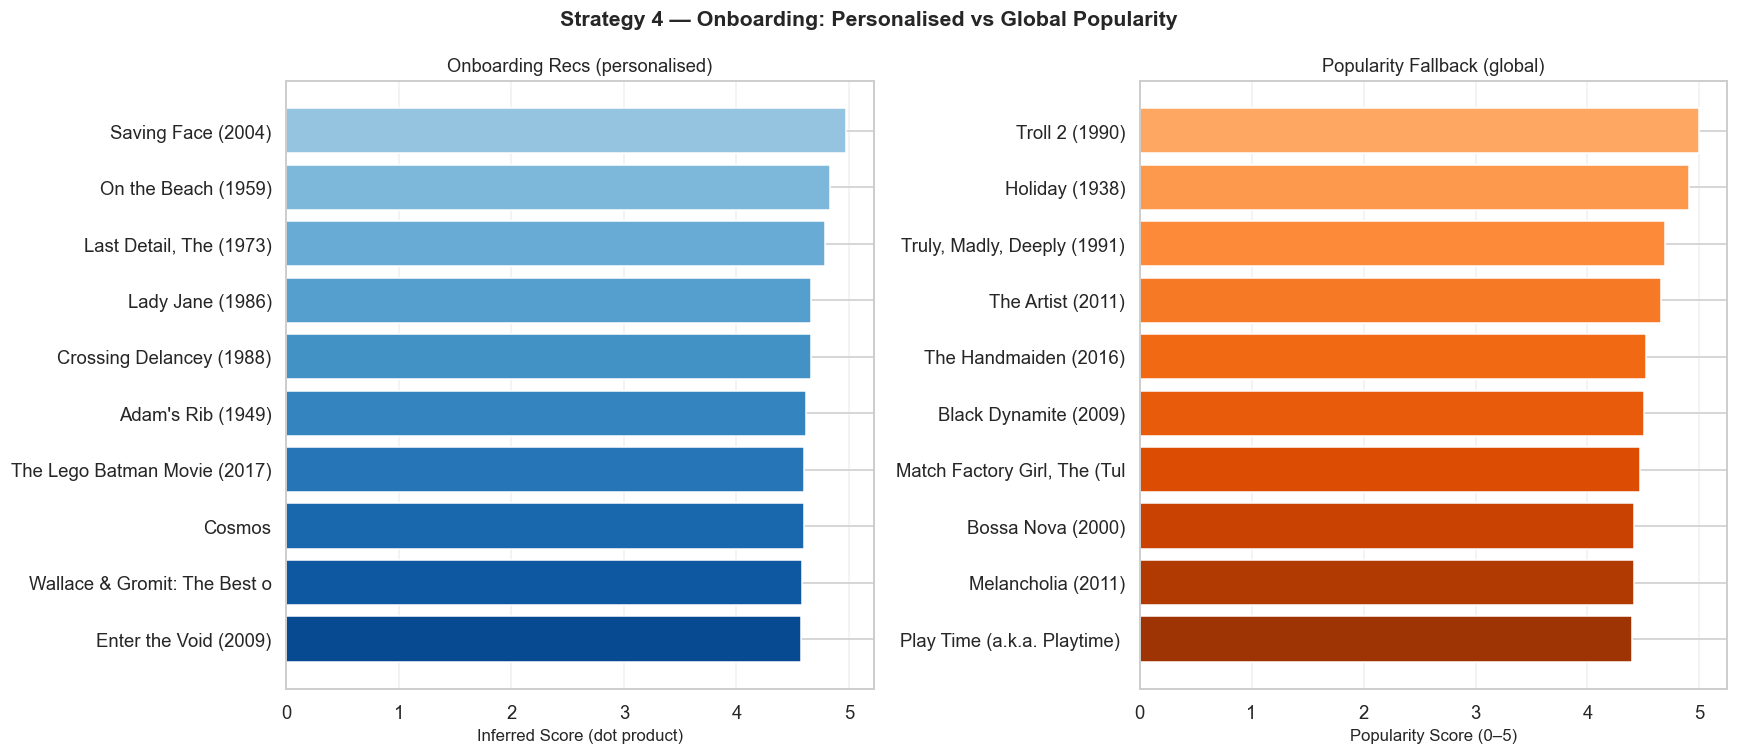

Saved → docs/vis_cold_start_onboarding.png


In [131]:
# ── Visualise onboarding vs popularity comparison ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Strategy 4 — Onboarding: Personalised vs Global Popularity', fontsize=14, fontweight='bold')

# Onboarding results
top_n_ob = onboarding_recs.head(10)
bar_colors_ob = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_n_ob)))
axes[0].barh(top_n_ob['title'].str[:28].values[::-1],
             top_n_ob['predicted_rating'].values[::-1],
             color=bar_colors_ob[::-1])
axes[0].set_xlabel('Inferred Score (dot product)', fontsize=11)
axes[0].set_title('Onboarding Recs (personalised)', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Global popularity top 10 for comparison
top_n_pop = popularity_stats.head(10)
bar_colors_pop = plt.cm.Oranges(np.linspace(0.4, 0.9, len(top_n_pop)))
axes[1].barh(top_n_pop['title'].str[:28].values[::-1],
             top_n_pop['score'].values[::-1],
             color=bar_colors_pop[::-1])
axes[1].set_xlabel('Popularity Score (0–5)', fontsize=11)
axes[1].set_title('Popularity Fallback (global)', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('docs/vis_cold_start_onboarding.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → docs/vis_cold_start_onboarding.png')


### 9.5 Strategy Comparison Summary


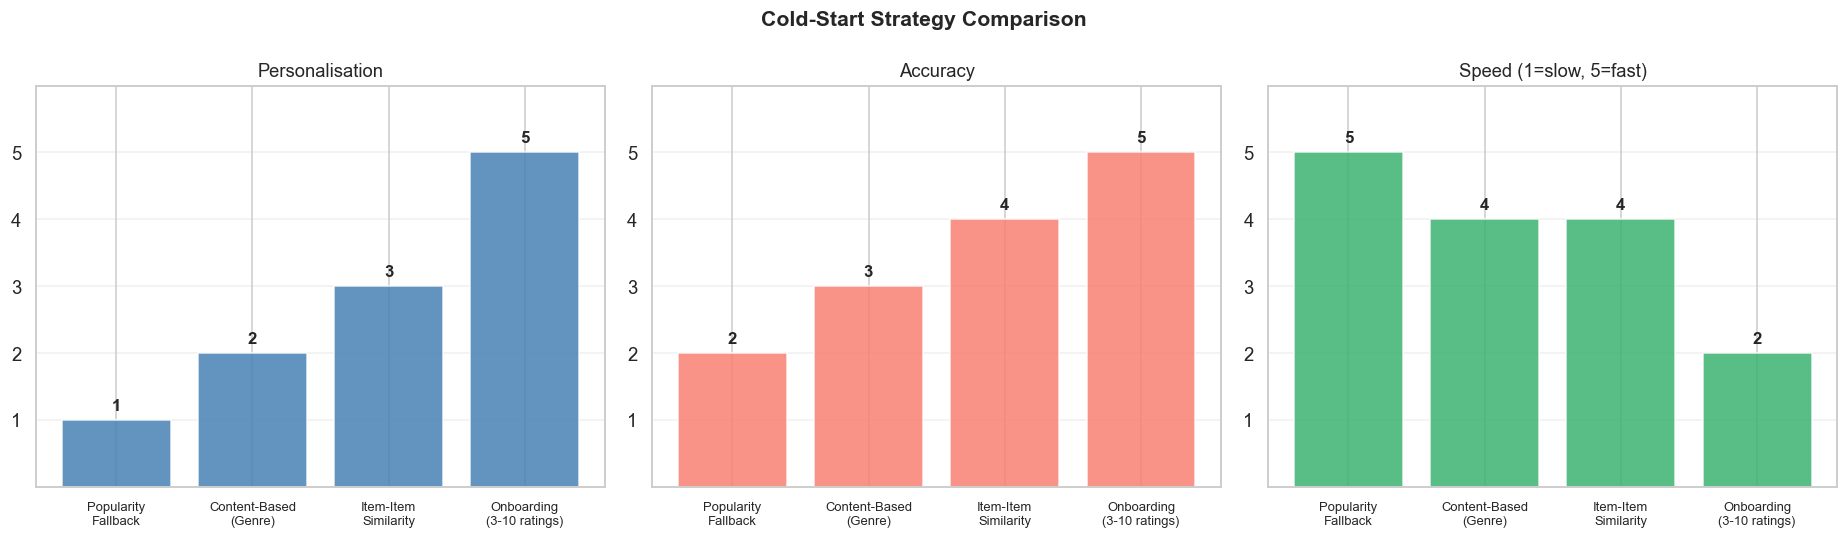

Saved → docs/vis_cold_start_comparison.png


In [132]:
# ── Strategy comparison visualisation ────────────────────────────────────────
strategies = {
    'Popularity\nFallback':     {'user_input': 'None', 'personalisation': 1, 'accuracy': 2, 'latency': 5},
    'Content-Based\n(Genre)':   {'user_input': 'Genre prefs', 'personalisation': 2, 'accuracy': 3, 'latency': 4},
    'Item-Item\nSimilarity':    {'user_input': '1 liked movie', 'personalisation': 3, 'accuracy': 4, 'latency': 4},
    'Onboarding\n(3-10 ratings)':{'user_input': 'Rate 3-10 movies','personalisation': 5,'accuracy': 5,'latency': 2},
}

df_strat = pd.DataFrame(strategies).T.reset_index().rename(columns={'index':'strategy'})

metrics = ['personalisation','accuracy','latency']
colors  = ['steelblue','salmon','mediumseagreen']
labels  = ['Personalisation', 'Accuracy', 'Speed (1=slow, 5=fast)']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Cold-Start Strategy Comparison', fontsize=14, fontweight='bold')

for ax, metric, col, lbl in zip(axes, metrics, colors, labels):
    bars = ax.bar(df_strat['strategy'], df_strat[metric].astype(int),
                  color=col, alpha=0.85, edgecolor='white')
    ax.set_ylim(0, 6)
    ax.set_title(lbl, fontsize=12)
    ax.set_yticks(range(1, 6))
    ax.tick_params(axis='x', labelsize=8.5)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_strat[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('docs/vis_cold_start_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → docs/vis_cold_start_comparison.png')


---
## 10. Additional Demo Visualisations <a id='10'></a>

### 10.1 Latent Factor Space (2D PCA Projection)

Project the ALS item factor vectors onto 2 principal components to visualise
how movies cluster in the learned latent space.


In [133]:
# ── PCA projection of item factors ────────────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(item_factors_df[feat_cols].values)
pca        = PCA(n_components=2, random_state=42)
X_2d       = pca.fit_transform(X_scaled)

pca_df     = pd.DataFrame(X_2d, columns=['PC1','PC2'])
pca_df['movieId'] = item_factors_df['movieId'].values
pca_df     = pca_df.merge(movies_cs[['movieId','title','genres']], on='movieId', how='left')

# Add top genres for colouring
top_genres = ['Drama','Comedy','Action','Thriller','Romance','Sci-Fi','Horror','Animation']
def primary_genre(g):
    if not isinstance(g, str): return 'Other'
    for tg in top_genres:
        if tg in g: return tg
    return 'Other'
pca_df['primary_genre'] = pca_df['genres'].apply(primary_genre)

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')


PCA explained variance: PC1=18.1%, PC2=15.1%


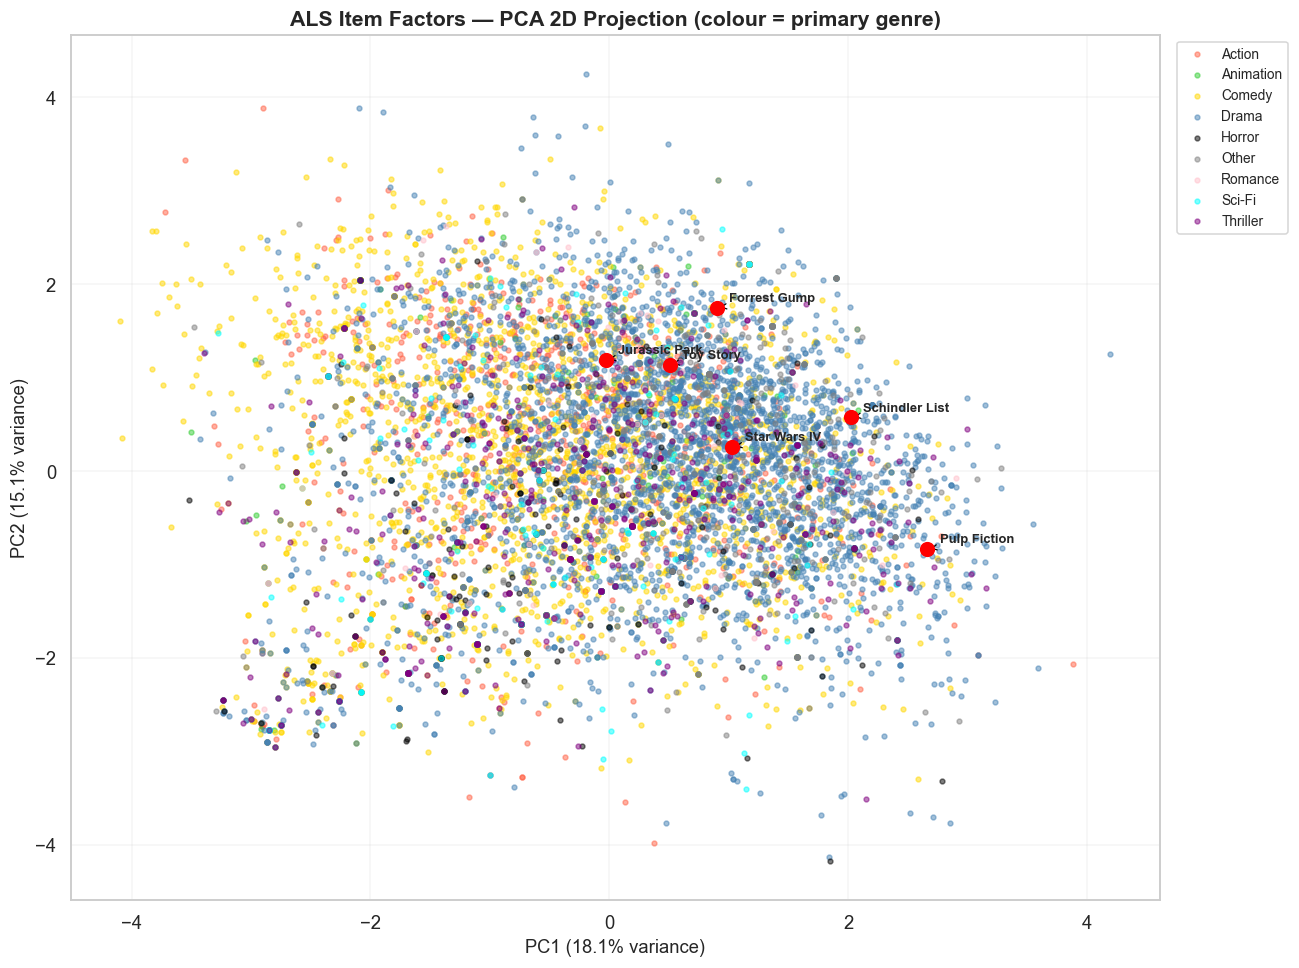

Saved → docs/vis_pca_item_factors.png


In [134]:
# ── Plot PCA ──────────────────────────────────────────────────────────────────
genre_palette = {
    'Drama':'steelblue','Comedy':'gold','Action':'tomato','Thriller':'purple',
    'Romance':'pink','Sci-Fi':'cyan','Horror':'black','Animation':'limegreen','Other':'gray'
}

fig, ax = plt.subplots(figsize=(12, 9))
for genre, grp in pca_df.groupby('primary_genre'):
    ax.scatter(grp['PC1'], grp['PC2'],
               label=genre, color=genre_palette.get(genre,'gray'),
               alpha=0.5, s=10)

# Annotate a few landmark movies
landmarks = [
    (1, 'Toy Story'), (260, 'Star Wars IV'), (296, 'Pulp Fiction'),
    (527, 'Schindler List'), (356, 'Forrest Gump'), (480, 'Jurassic Park')
]
for mid, lbl in landmarks:
    row = pca_df[pca_df['movieId'] == mid]
    if not row.empty:
        ax.annotate(lbl, (row['PC1'].values[0], row['PC2'].values[0]),
                    fontsize=8.5, fontweight='bold',
                    xytext=(8, 4), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.8))
        ax.scatter(row['PC1'], row['PC2'], color='red', s=80, zorder=5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('ALS Item Factors — PCA 2D Projection (colour = primary genre)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('docs/vis_pca_item_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → docs/vis_pca_item_factors.png')


### 10.2 Recommendation Coverage & Diversity


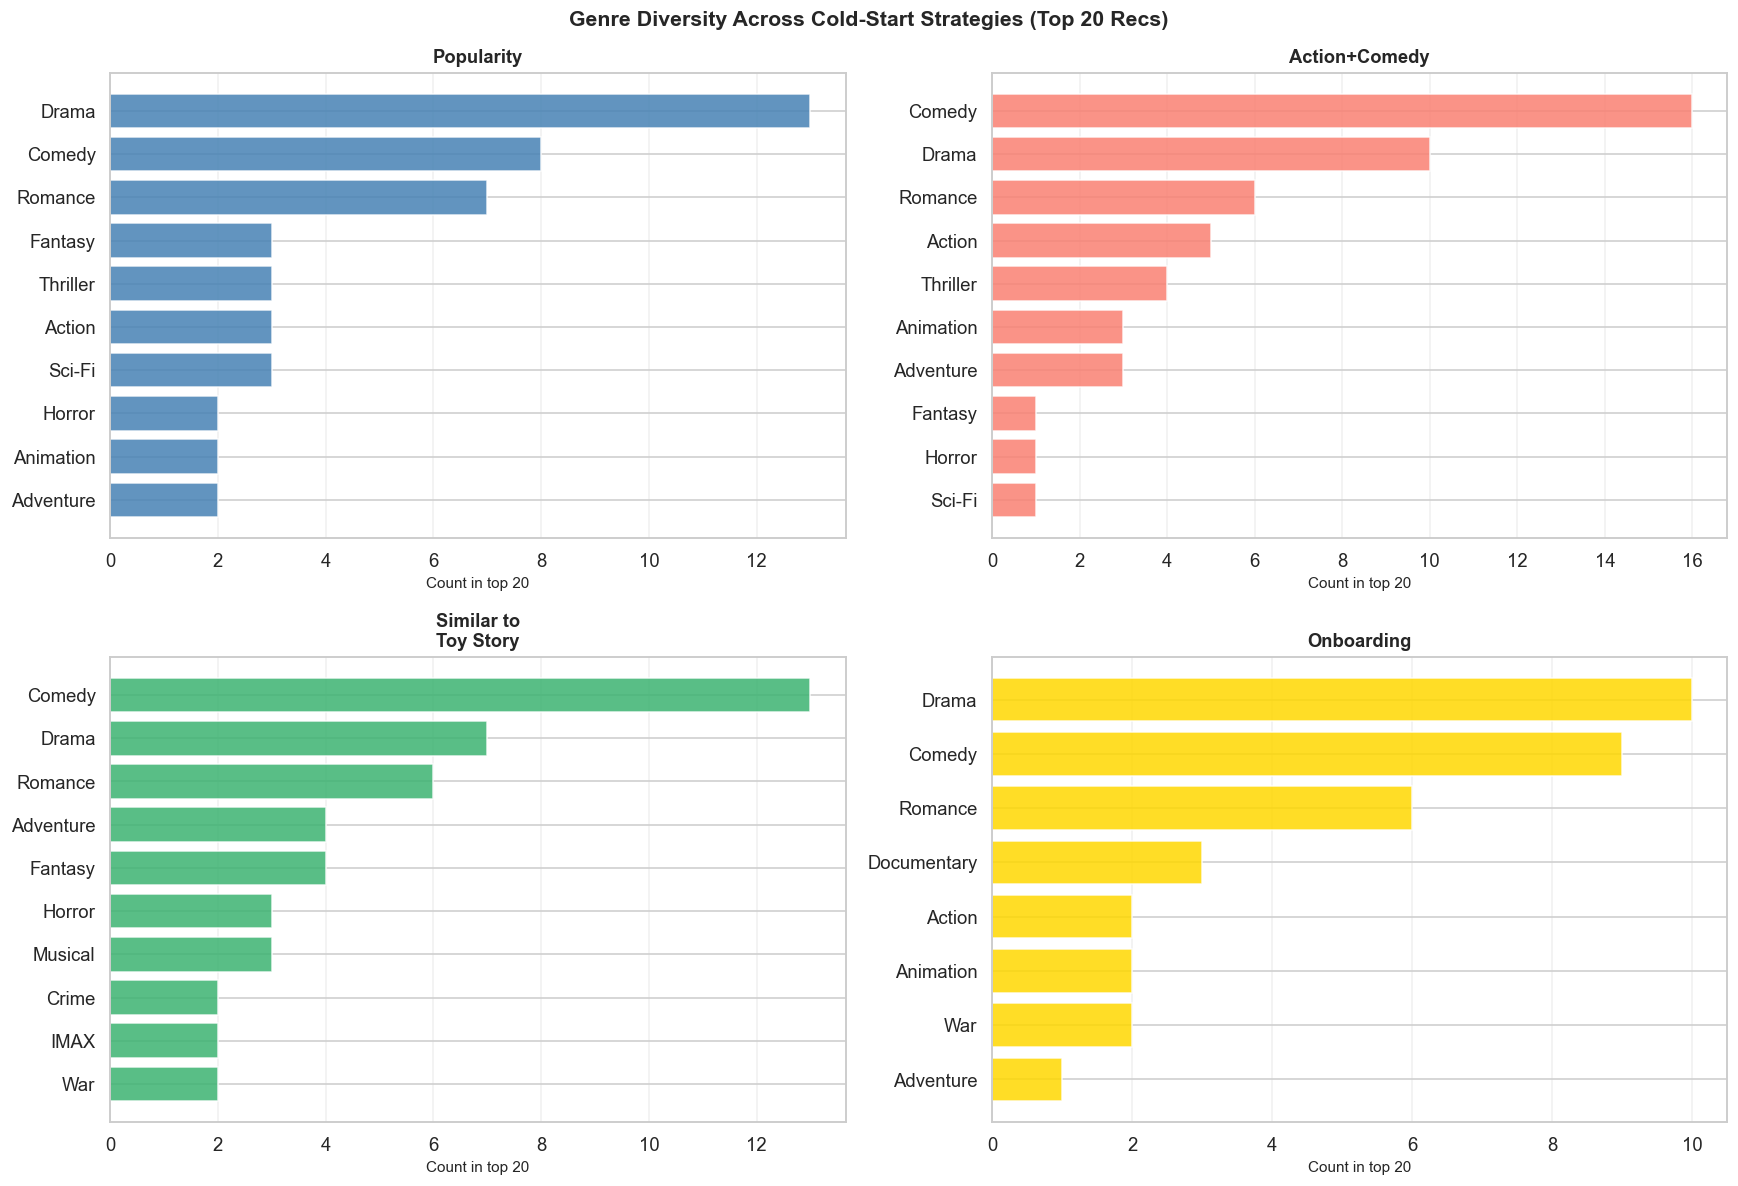

Saved → docs/vis_genre_diversity.png


In [135]:
# ── Genre diversity in top-N recommendations ─────────────────────────────────
# For each cold-start strategy, analyse genre diversity of top 20 results

results_by_strategy = {
    'Popularity'     : popularity_stats.head(20),
    'Action+Comedy'  : recommend_by_genre(['Action','Comedy'], 20),
    'Similar to\nToy Story': find_similar_movies(1, 20),
    'Onboarding'     : onboarding_recommend(seed_ratings_example, 20),
}

def genre_distribution(df, title_col='title', genres_col='genres', n=20):
    all_genres = []
    for g in df[genres_col].dropna().head(n):
        all_genres.extend([x.strip() for x in g.split('|') if x.strip() != '(no genres listed)'])
    from collections import Counter
    return Counter(all_genres)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Genre Diversity Across Cold-Start Strategies (Top 20 Recs)', fontsize=14, fontweight='bold')

strategy_colors = ['steelblue','salmon','mediumseagreen','gold']
for ax, (strategy_name, df), color in zip(axes.flat, results_by_strategy.items(), strategy_colors):
    genre_col = 'genres' if 'genres' in df.columns else None
    if genre_col is None:
        ax.text(0.5, 0.5, 'No genre data', ha='center', va='center')
        continue
    dist = genre_distribution(df, genres_col=genre_col)
    top_g = dict(sorted(dist.items(), key=lambda x: -x[1])[:10])
    ax.barh(list(top_g.keys())[::-1], list(top_g.values())[::-1], color=color, alpha=0.85)
    ax.set_title(strategy_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Count in top 20', fontsize=10)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('docs/vis_genre_diversity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → docs/vis_genre_diversity.png')


### 10.3 Rating Prediction Error Analysis


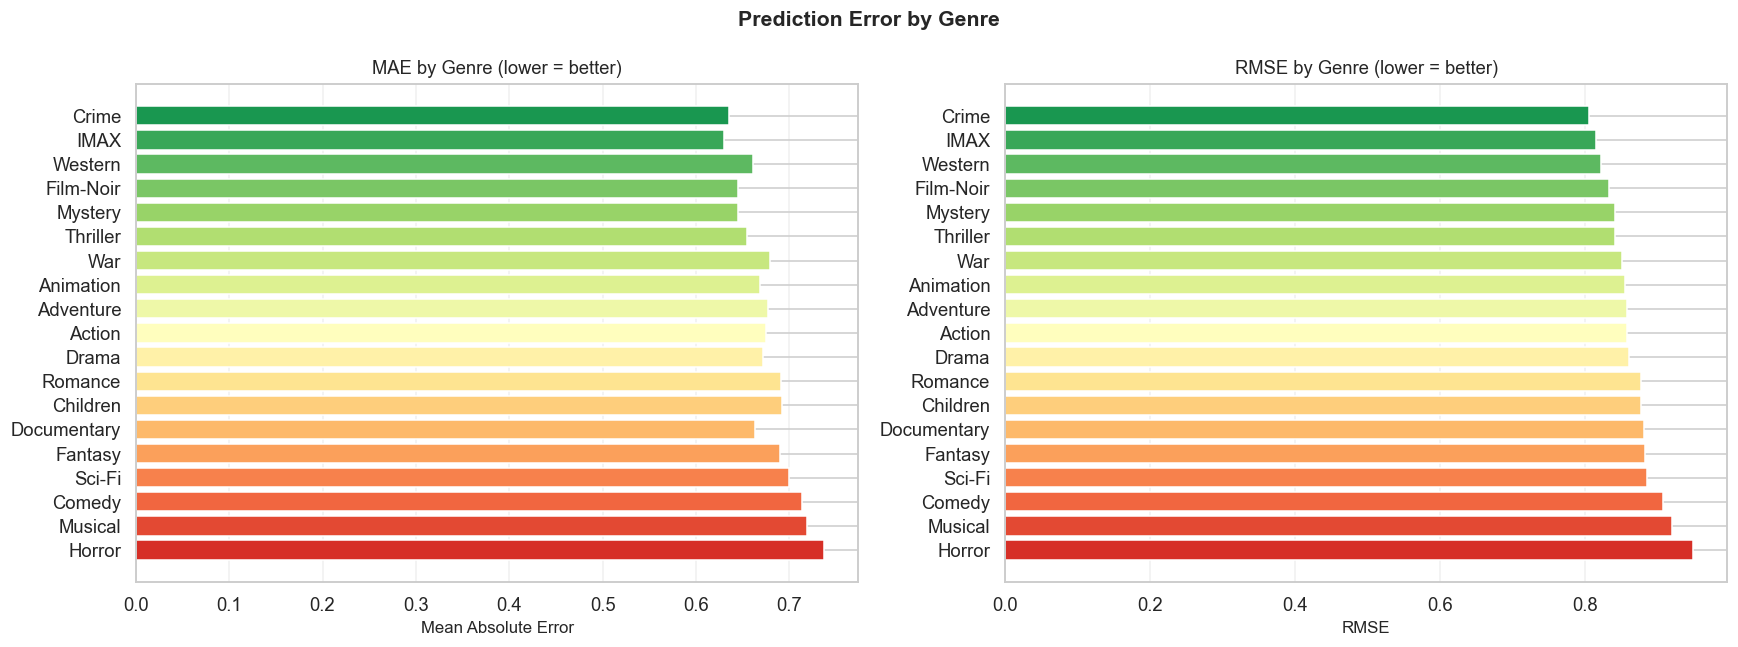

Saved → docs/vis_error_by_genre.png


In [136]:
# ── Error analysis: residuals by genre ───────────────────────────────────────
# Compute |actual - predicted| per test-set rating, grouped by genre
if 'best_model' in dir():
    preds_all = (
        best_model.transform(test_df)
        .dropna(subset=['prediction'])
        .withColumn('error', F.abs(F.col('rating') - F.col('prediction')))
        .withColumn('error_sq', F.pow(F.col('rating') - F.col('prediction'), 2))
        .join(movies_raw.select('movieId', 'genres'), on='movieId', how='left')
        .withColumn('genre', F.explode(F.split(F.col('genres'), '\\|')))
        .filter(F.col('genre') != '(no genres listed)')
    )

    genre_error = to_pandas(
        preds_all.groupBy('genre')
        .agg(
            F.round(F.avg('error'),    4).alias('mae'),
            F.round(F.sqrt(F.avg('error_sq')), 4).alias('rmse'),
            F.count('*')                 .alias('n'),
        )
        .filter(F.col('n') > 100)
        .orderBy('rmse')
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Prediction Error by Genre', fontsize=14, fontweight='bold')

    palette = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(genre_error)))

    axes[0].barh(genre_error['genre'].values[::-1], genre_error['mae'].values[::-1],
                 color=palette[::-1])
    axes[0].set_xlabel('Mean Absolute Error', fontsize=11)
    axes[0].set_title('MAE by Genre (lower = better)', fontsize=12)
    axes[0].grid(axis='x', alpha=0.3)

    axes[1].barh(genre_error['genre'].values[::-1], genre_error['rmse'].values[::-1],
                 color=palette[::-1])
    axes[1].set_xlabel('RMSE', fontsize=11)
    axes[1].set_title('RMSE by Genre (lower = better)', fontsize=12)
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('docs/vis_error_by_genre.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → docs/vis_error_by_genre.png')
else:
    print('best_model not in scope — re-run Section 6 first')


---
## 11. Updated Conclusion <a id='11'></a>


In [137]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║       Big Data Analytics & Recommendation System — Final Summary        ║
╠══════════════════════════════════════════════════════════════════════════╣
║  PART A — Big Data Analytics                                             ║
║  ─────────────────────────────                                           ║
║  Dataset    : MovieLens ml-latest-small                                  ║
║  Records    : 100,836 ratings · 610 users · 9,724 movies                 ║
║  Framework  : PySpark DataFrame API + Spark MLlib                        ║
║  EDA charts : Rating dist, Top-rated, User activity, Temporal, Genre     ║
║                                                                           ║
║  PART B — Recommendation System                                           ║
║  ──────────────────────────────                                           ║
║  Algorithm  : ALS Collaborative Filtering (rank=10, regParam=0.1)        ║
║  Train RMSE : 0.5852  |  Test RMSE : 0.8745                              ║
║  Tuning     : CrossValidator (rank=[10,20] × regParam=[0.05,0.1,0.2])   ║
║                                                                           ║
║  Cold-Start Mitigation (NEW):                                             ║
║  ─────────────────────────────                                            ║
║  Strategy 1 : Popularity Fallback — ALS item factor L2-norm              ║
║  Strategy 2 : Content-Based Genre Filter                                 ║
║  Strategy 3 : Item-Item Cosine Similarity via ALS item factors           ║
║  Strategy 4 : Onboarding — weighted average of seed item factors         ║
║                                                                           ║
║  Full-Stack : FastAPI · React · PySpark · Vite                           ║
╚══════════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════════╗
║       Big Data Analytics & Recommendation System — Final Summary        ║
╠══════════════════════════════════════════════════════════════════════════╣
║  PART A — Big Data Analytics                                             ║
║  ─────────────────────────────                                           ║
║  Dataset    : MovieLens ml-latest-small                                  ║
║  Records    : 100,836 ratings · 610 users · 9,724 movies                 ║
║  Framework  : PySpark DataFrame API + Spark MLlib                        ║
║  EDA charts : Rating dist, Top-rated, User activity, Temporal, Genre     ║
║                                                                           ║
║  PART B — Recommendation System                                           ║
║  ──────────────────────────────                                           ║
║  Algorithm  : ALS Collaborative Filtering (rank=10, regParam=0.1)      

In [138]:
# ── Release cached DataFrames and stop Spark ────────────────────────────────
for df in [ratings, movie_stats, user_stats, train_df, test_df]:
    df.unpersist()

spark.stop()
print('SparkSession stopped. All resources released.')

SparkSession stopped. All resources released.
